# Notebook 06: Hands-On with V-JEPA 2-AC (Action-Conditioned World Model)

## What You Will Learn

This notebook walks through the **real V-JEPA 2 codebase** from `refs/vjepa2/`, building and running CPU-compatible versions of every major component.

**Sections 1--4 (this half):**
1. **Environment Setup** -- imports, path configuration, hardware check
2. **Real Encoder Architecture** -- read the actual `VisionTransformer` source, build a CPU-compatible ViT-Large equivalent, compare model sizes
3. **Real AC Predictor Architecture** -- read the actual `VisionTransformerPredictorAC`, build a working replica with causal masking
4. **ACBlock & ACRoPEAttention Deep Dive** -- how action tokens get 1D RoPE while spatial tokens get 3D RoPE

**Hardware notes:** All code runs on CPU. If you have an NVIDIA GPU (e.g., RTX 5090 24 GB), model instantiation and forward passes will automatically use it for speed. The notebook detects and reports your hardware at startup.

**Prerequisites:** Notebooks 01--05 (especially 02 and 03 for architecture context).

In [1]:
# === Section 1: Environment Setup ===
import sys, os, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'
sys.path.insert(0, str(VJEPA2_ROOT))
print(f"V-JEPA 2 root: {VJEPA2_ROOT}")
print(f"Exists: {VJEPA2_ROOT.exists()}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
else:
    print("Running on CPU (all code is CPU-compatible)")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# Verify key source files exist
key_files = [
    'src/models/vision_transformer.py',
    'src/models/ac_predictor.py',
    'src/models/utils/modules.py',
]
print("\nKey source files:")
for f in key_files:
    path = VJEPA2_ROOT / f
    status = 'OK' if path.exists() else 'MISSING'
    print(f"  [{status}] {f}")

V-JEPA 2 root: D:\Work\JEPAstudy\refs\vjepa2
Exists: True
CUDA available: False
Running on CPU (all code is CPU-compatible)

Key source files:
  [OK] src/models/vision_transformer.py
  [OK] src/models/ac_predictor.py
  [OK] src/models/utils/modules.py


### Reading the output

You should see:
- **V-JEPA 2 root** pointing to `refs/vjepa2` -- this is Meta's open-source repository.
- **CUDA** -- `True` if you have an NVIDIA GPU, `False` if CPU-only. Either way the notebook works.
- **Key source files** -- all three should show `[OK]`. If any are `MISSING`, re-clone the vjepa2 repo.

---

## Section 2: Real Encoder Architecture -- VisionTransformer

### 5W1H

| Question | Answer |
|----------|--------|
| **What?** | `VisionTransformer` -- the encoder that converts raw video frames into latent patch embeddings |
| **Why?** | The encoder produces the target representations that the predictor must learn to predict. It is the backbone of the entire JEPA system. |
| **Where?** | `refs/vjepa2/src/models/vision_transformer.py` |
| **When?** | Used during both training (as context encoder AND EMA target encoder) and inference |
| **Who?** | Meta FAIR -- same architecture for V-JEPA 2 pretraining and the AC world model |
| **How?** | 3D patch embedding (spatiotemporal tubelets) followed by Transformer blocks with 3D RoPE |

In [2]:
# Read the actual VisionTransformer source code
import sys, os
from pathlib import Path
VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

try:
    import inspect
    sys.path.insert(0, str(VJEPA2_ROOT))
    from src.models.vision_transformer import VisionTransformer
    source = inspect.getsource(VisionTransformer.__init__)
    print("=== VisionTransformer.__init__ (imported successfully) ===")
    print(source[:2500])
except (ImportError, ModuleNotFoundError) as e:
    print(f"Cannot import VisionTransformer: {e}")
    print("Reading source file directly...\n")
    with open(VJEPA2_ROOT / 'src/models/vision_transformer.py') as f:
        content = f.read()
    start = content.find('class VisionTransformer')
    print(content[start:start+2500])

Cannot import VisionTransformer: No module named 'timm'
Reading source file directly...

class VisionTransformer(nn.Module):
    """Vision Transformer"""

    def __init__(
        self,
        img_size=(224, 224),
        patch_size=16,
        num_frames=1,
        tubelet_size=2,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        norm_layer=nn.LayerNorm,
        init_std=0.02,
        out_layers=None,
        uniform_power=False,
        use_silu=False,
        wide_silu=True,
        use_sdpa=True,
        use_activation_checkpointing=False,
        use_rope=False,
        handle_nonsquare_inputs=True,
        **kwargs
    ):
        super().__init__()
        self.num_features = self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.out_layers = out_layers
        self.handle

### Key Components in `VisionTransformer.__init__`

Reading through the real source, the encoder has three main pieces:

1. **`PatchEmbed3D`** -- A 3D convolution that chops the input video `[B, 3, T, H, W]` into spatiotemporal tubelets. With `patch_size=16` and `tubelet_size=2`, each tubelet covers 2 frames x 16 pixels x 16 pixels. Output: one embedding vector per tubelet.

2. **`Block` layers** (depth of them) -- Standard Transformer blocks, each containing:
   - `LayerNorm` (pre-norm)
   - `RoPEAttention` or `Attention` (multi-head self-attention with optional 3D rotary position embeddings)
   - `MLP` or `SwiGLUFFN` (feedforward network)
   - Residual connections around both sub-layers

3. **`LayerNorm`** -- Final normalization before output.

Notable details:
- `use_rope=True` enables **3D Rotary Position Embeddings** -- positions are encoded along (depth, height, width) axes.
- `out_layers` allows extracting intermediate layer outputs (useful for multi-scale features).
- The encoder does NOT use action conditioning -- that is the predictor's job.

In [3]:
# Build a ViT-Large equivalent using standard PyTorch (CPU-compatible, no xformers)
import torch
import torch.nn as nn

class MiniViTEncoder(nn.Module):
    """Simplified VisionTransformer matching V-JEPA 2 ViT-Large config.
    
    This uses standard PyTorch TransformerEncoder instead of the custom
    RoPEAttention blocks (which require xformers). The architecture is
    structurally equivalent: same embed_dim, depth, num_heads, and
    patch embedding strategy.
    """
    def __init__(self, img_size=256, patch_size=16, in_chans=3,
                 embed_dim=1024, depth=24, num_heads=16,
                 tubelet_size=2, num_frames=8):
        super().__init__()
        # 3D patch embedding: Conv3d acts as the tubelet tokenizer
        self.patch_embed = nn.Conv3d(
            in_chans, embed_dim,
            kernel_size=(tubelet_size, patch_size, patch_size),
            stride=(tubelet_size, patch_size, patch_size))
        
        self.num_patches_spatial = (img_size // patch_size) ** 2  # 16x16 = 256
        self.num_patches_temporal = num_frames // tubelet_size    # 8/2 = 4
        self.num_patches = self.num_patches_spatial * self.num_patches_temporal  # 1024
        
        # Standard Transformer blocks (pre-norm, GELU activation)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            activation='gelu', batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim

    def forward(self, x):
        """Forward pass.
        Args:
            x: [B, C, T, H, W] = [B, 3, 8, 256, 256] video tensor
        Returns:
            [B, N, D] patch embeddings where N = T' * H' * W'
        """
        x = self.patch_embed(x)           # [B, D, T', H', W']
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        x = self.blocks(x)
        x = self.norm(x)
        return x

# Instantiate and inspect
encoder = MiniViTEncoder()
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {total_params:,} ({total_params / 1e6:.1f}M)")
print(f"\nViT-Large config (matching V-JEPA 2):")
print(f"  embed_dim   = 1024")
print(f"  depth       = 24 blocks")
print(f"  num_heads   = 16")
print(f"  head_dim    = {1024 // 16} = 64")
print(f"  Spatial patches  = 16 x 16 = 256 per frame")
print(f"  Temporal tokens  = 8 frames / 2 tubelet = 4")
print(f"  Total tokens     = 4 x 256 = 1024")

# Forward pass with dummy video
torch.manual_seed(42)
video = torch.randn(1, 3, 8, 256, 256)
print(f"\nInput video shape: {video.shape}")
print(f"  = [batch=1, channels=3, frames=8, height=256, width=256]")
with torch.no_grad():
    output = encoder(video)
print(f"\nOutput embeddings: {output.shape}")
print(f"  = [batch={output.shape[0]}, tokens={output.shape[1]}, embed_dim={output.shape[2]}]")
print(f"  1024 tokens = 4 temporal x 256 spatial")

C:\Users\jeffr\AppData\Local\Temp\ipykernel_24616\2944024098.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)


Encoder parameters: 303,885,312 (303.9M)

ViT-Large config (matching V-JEPA 2):
  embed_dim   = 1024
  depth       = 24 blocks
  num_heads   = 16
  head_dim    = 64 = 64
  Spatial patches  = 16 x 16 = 256 per frame
  Temporal tokens  = 8 frames / 2 tubelet = 4
  Total tokens     = 4 x 256 = 1024

Input video shape: torch.Size([1, 3, 8, 256, 256])
  = [batch=1, channels=3, frames=8, height=256, width=256]



Output embeddings: torch.Size([1, 1024, 1024])
  = [batch=1, tokens=1024, embed_dim=1024]
  1024 tokens = 4 temporal x 256 spatial


### Understanding the output

The encoder converts an 8-frame video at 256x256 resolution into **1024 patch embeddings**, each of dimension 1024.

Here is how the tokenization works:

```
Input:  [1, 3, 8, 256, 256]   -- 1 video, 3 channels, 8 frames, 256x256
                |
         PatchEmbed3D (Conv3d)
         kernel = (2, 16, 16), stride = (2, 16, 16)
                |
        [1, 1024, 4, 16, 16]   -- 1024-dim, 4 temporal, 16x16 spatial
                |
         flatten + transpose
                |
        [1, 1024, 1024]        -- 1024 tokens, each 1024-dim
                |
         24 Transformer blocks
                |
        [1, 1024, 1024]        -- contextualized embeddings
```

The parameter count (~303M) is close to ViT-Large. The slight difference from the canonical 304M is due to using `nn.TransformerEncoderLayer` (which fuses QKV differently) instead of the custom blocks.

In [4]:
# Model size comparison across ViT variants
configs = {
    'ViT-Base':  {'D':  768, 'depth': 12, 'heads': 12, 'params_M':  86},
    'ViT-Large': {'D': 1024, 'depth': 24, 'heads': 16, 'params_M': 304},
    'ViT-Huge':  {'D': 1280, 'depth': 32, 'heads': 16, 'params_M': 632},
    'ViT-Giant': {'D': 1408, 'depth': 40, 'heads': 22, 'params_M': 1136},
}

print(f"{'Model':<12} {'D':>6} {'Depth':>6} {'Heads':>6} {'Params':>10} {'VRAM (fp16)':>12} {'RTX 5090?':>10}")
print("-" * 70)
for name, c in configs.items():
    vram = c['params_M'] * 2 / 1000  # fp16 = 2 bytes per param, convert to GB
    fits = 'YES' if vram < 20 else 'TIGHT' if vram < 24 else 'NO'
    print(f"{name:<12} {c['D']:>6} {c['depth']:>6} {c['heads']:>6} {c['params_M']:>8}M {vram:>10.1f}GB {fits:>10}")

print("\nNote: VRAM estimate is for model weights only (fp16).")
print("Actual training VRAM is 3-4x higher due to activations, gradients, optimizer states.")
print("V-JEPA 2 uses ViT-Large (304M) for the encoder and ViT-Huge (632M) for the largest variant.")

Model             D  Depth  Heads     Params  VRAM (fp16)  RTX 5090?
----------------------------------------------------------------------
ViT-Base        768     12     12       86M        0.2GB        YES
ViT-Large      1024     24     16      304M        0.6GB        YES
ViT-Huge       1280     32     16      632M        1.3GB        YES
ViT-Giant      1408     40     22     1136M        2.3GB        YES

Note: VRAM estimate is for model weights only (fp16).
Actual training VRAM is 3-4x higher due to activations, gradients, optimizer states.
V-JEPA 2 uses ViT-Large (304M) for the encoder and ViT-Huge (632M) for the largest variant.


### Reading guide for the parameter table

- **D** (embed_dim): The hidden dimension throughout the Transformer. Larger D means each token carries more information but costs more compute.
- **Depth**: Number of Transformer blocks stacked. More depth gives more expressive power.
- **Heads**: Number of attention heads. Each head has dimension `D / heads`.
- **VRAM (fp16)**: Minimum GPU memory just to store the model weights in half-precision. Training requires 3--4x more.
- **RTX 5090?**: Whether the model weights alone fit in 24 GB. V-JEPA 2's ViT-Large (304M) fits comfortably; ViT-Giant would not.

V-JEPA 2 uses **ViT-Large** as its default encoder configuration.

---

## Section 3: Real AC Predictor Architecture -- VisionTransformerPredictorAC

### 5W1H

| Question | Answer |
|----------|--------|
| **What?** | `VisionTransformerPredictorAC` -- the action-conditioned predictor that forecasts future latent representations given current observations and robot actions |
| **Why?** | This is the **world model**. Given "what the robot sees now" + "what action it takes", it predicts "what it will see next" -- all in latent space. |
| **Where?** | `refs/vjepa2/src/models/ac_predictor.py` |
| **When?** | During AC training (teacher forcing + autoregressive) and at inference for planning (e.g., CEM) |
| **Who?** | Meta FAIR -- extends the standard V-JEPA predictor with action and state conditioning |
| **How?** | Interleaves action/state tokens with visual patch tokens per frame, applies frame-causal attention |

### What makes it different from the standard predictor?

The standard V-JEPA predictor only predicts masked patches from visible patches (no actions). The AC predictor adds:
1. **Action encoder** -- projects robot actions (7-DoF: 6 joints + gripper) into the predictor's hidden dimension
2. **State encoder** -- projects proprioceptive state into the same space
3. **Frame-causal attention mask** -- each frame can only attend to itself and past frames (not future)
4. **Token interleaving** -- action and state tokens are prepended to each frame's spatial tokens

In [5]:
# Read the actual AC predictor forward pass
import os
from pathlib import Path
VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

with open(VJEPA2_ROOT / 'src/models/ac_predictor.py') as f:
    content = f.read()

# Show the forward method
start = content.find('def forward(')
end = content.find('\ndef ', start + 1)
if end < 0:
    end = content.find('\nclass ', start + 1)
if end < 0:
    end = start + 3000
print("=== VisionTransformerPredictorAC.forward() ===")
print(content[start:end])

=== VisionTransformerPredictorAC.forward() ===
def forward(self, x, actions, states, extrinsics=None):
        """
        :param x: context tokens
        """
        # Map tokens to predictor dimensions
        x = self.predictor_embed(x)
        B, N_ctxt, D = x.size()
        T = N_ctxt // (self.grid_height * self.grid_width)

        # Interleave action tokens
        s = self.state_encoder(states).unsqueeze(2)
        a = self.action_encoder(actions).unsqueeze(2)
        x = x.view(B, T, self.grid_height * self.grid_width, D)  # [B, T, H*W, D]
        if self.use_extrinsics:
            e = self.extrinsics_encoder(extrinsics).unsqueeze(2)
            x = torch.cat([a, s, e, x], dim=2).flatten(1, 2)  # [B, T*(H*W+3), D]
        else:
            x = torch.cat([a, s, x], dim=2).flatten(1, 2)  # [B, T*(H*W+2), D]

        cond_tokens = 3 if self.use_extrinsics else 2
        attn_mask = self.attn_mask[: x.size(1), : x.size(1)].to(x.device, non_blocking=True)

        # Fwd prop
    

### Forward pass step-by-step

Here is exactly what happens in `VisionTransformerPredictorAC.forward(x, actions, states)`:

1. **Project to predictor dimension**: `x = self.predictor_embed(x)` maps encoder output (1024-dim for ViT-Large) to the predictor's own hidden dimension (e.g., 512 or 768). This dimensionality reduction is intentional -- the predictor should be smaller than the encoder.

2. **Encode actions & states**: `self.action_encoder(actions)` and `self.state_encoder(states)` each project the 7-DoF robot signals into the predictor dimension. These become single tokens per frame.

3. **Reshape to per-frame layout**: `x.view(B, T, H*W, D)` separates the flat token sequence back into `T` frames, each with `H*W` spatial tokens.

4. **Interleave tokens**: `torch.cat([a, s, x], dim=2)` prepends action and state tokens before each frame's spatial patches. Result: each frame has `[action, state, patch_0, patch_1, ..., patch_255]` = 258 tokens.

5. **Flatten back**: `.flatten(1, 2)` merges frames into one long sequence: `[B, T*(H*W+2), D]`.

6. **Apply causal transformer**: Each `ACBlock` processes the sequence with frame-causal attention -- frame 0 sees only itself, frame 1 sees frames 0 and 1, etc.

7. **Extract spatial predictions**: After the transformer, strip out the action/state tokens, keeping only the spatial patch predictions. Apply final norm and project back to encoder dimension.

**Key insight**: The predictor output has the SAME shape as the encoder output `[B, T*H*W, embed_dim]`. This is because the L1 training loss compares predictor output directly to the EMA encoder's target representations.

In [6]:
# Build a CPU-compatible AC predictor matching V-JEPA 2-AC architecture
import torch
import torch.nn as nn

class MiniACPredictor(nn.Module):
    """Simplified AC predictor matching V-JEPA 2-AC architecture.
    
    Uses standard PyTorch modules instead of ACRoPEAttention + ACBlock.
    Structurally equivalent: same token interleaving, causal masking,
    and dimension projections.
    """
    def __init__(self, embed_dim=1024, predictor_embed_dim=512,
                 action_dim=7, depth=12, num_heads=8,
                 grid_height=16, grid_width=16, num_frames=4):
        super().__init__()
        self.predictor_embed = nn.Linear(embed_dim, predictor_embed_dim)
        self.action_encoder = nn.Linear(action_dim, predictor_embed_dim)
        self.state_encoder = nn.Linear(action_dim, predictor_embed_dim)
        self.grid_height = grid_height
        self.grid_width = grid_width
        self.num_frames = num_frames

        # Transformer blocks (pre-norm, GELU)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=predictor_embed_dim, nhead=num_heads,
            dim_feedforward=predictor_embed_dim * 4, activation='gelu',
            batch_first=True, norm_first=True)
        self.predictor_blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.predictor_norm = nn.LayerNorm(predictor_embed_dim)
        self.predictor_proj = nn.Linear(predictor_embed_dim, embed_dim)

        # Build frame-causal attention mask
        # This replicates build_action_block_causal_attention_mask from modules.py
        # Convention: True = BLOCKED, passed as additive mask (True -> -inf)
        tokens_per_frame = grid_height * grid_width + 2  # +2 for action + state
        total_tokens = num_frames * tokens_per_frame
        # Start with all blocked
        mask = torch.ones(total_tokens, total_tokens, dtype=torch.bool)
        for t1 in range(num_frames):
            for t2 in range(t1 + 1):  # Can attend to current and all past frames
                row_start = t1 * tokens_per_frame
                row_end = (t1 + 1) * tokens_per_frame
                col_start = t2 * tokens_per_frame
                col_end = (t2 + 1) * tokens_per_frame
                mask[row_start:row_end, col_start:col_end] = False
        # nn.TransformerEncoder expects: True = blocked position
        self.register_buffer('causal_mask', mask)

    def forward(self, context_tokens, actions, states):
        """
        Args:
            context_tokens: [B, T*H*W, embed_dim] from encoder
            actions: [B, T, action_dim] robot actions per frame
            states: [B, T, action_dim] proprioceptive states per frame
        Returns:
            [B, T*H*W, embed_dim] predicted latent patches
        """
        B = context_tokens.shape[0]
        T = self.num_frames
        HW = self.grid_height * self.grid_width

        # Step 1: Project to predictor dimension
        x = self.predictor_embed(context_tokens)  # [B, T*HW, D_pred]
        D = x.shape[-1]
        x = x.view(B, T, HW, D)  # [B, T, HW, D_pred]

        # Step 2: Encode actions and states
        a = self.action_encoder(actions).unsqueeze(2)  # [B, T, 1, D_pred]
        s = self.state_encoder(states).unsqueeze(2)    # [B, T, 1, D_pred]

        # Step 3: Interleave [action, state, patches...] per frame
        x = torch.cat([a, s, x], dim=2)  # [B, T, 2+HW, D_pred]
        x = x.flatten(1, 2)              # [B, T*(2+HW), D_pred]

        # Step 4: Apply causal transformer
        x = self.predictor_blocks(x, mask=self.causal_mask)

        # Step 5: Extract spatial predictions only (strip action/state tokens)
        tokens_per_frame = HW + 2
        x = x.view(B, T, tokens_per_frame, D)  # [B, T, 2+HW, D]
        x = x[:, :, 2:, :]                     # [B, T, HW, D]  -- drop action+state
        x = x.flatten(1, 2)                     # [B, T*HW, D]

        # Step 6: Normalize and project back to encoder dimension
        x = self.predictor_norm(x)
        x = self.predictor_proj(x)
        return x

# Instantiate and test
torch.manual_seed(42)
predictor = MiniACPredictor()
pred_params = sum(p.numel() for p in predictor.parameters())
print(f"AC Predictor parameters: {pred_params:,} ({pred_params / 1e6:.1f}M)")

# Forward pass with dummy data
context = torch.randn(1, 4 * 256, 1024)  # [B, T*HW, D]  -- 4 frames x 256 patches
actions = torch.randn(1, 4, 7)            # [B, T, 7]     -- 7-DoF per frame
states  = torch.randn(1, 4, 7)            # [B, T, 7]     -- proprioception

with torch.no_grad():
    preds = predictor(context, actions, states)

print(f"\nInput context:  {context.shape} = [B, T*HW, D]")
print(f"Input actions:  {actions.shape} = [B, T, action_dim]")
print(f"Input states:   {states.shape} = [B, T, state_dim]")
print(f"Output preds:   {preds.shape} = [B, T*HW, D]")
print(f"\nOutput matches encoder output shape: {preds.shape == context.shape}")
print(f"This is required for the L1 loss: |predictor(x) - EMA_encoder(y)|")

AC Predictor parameters: 38,887,936 (38.9M)


C:\Users\jeffr\AppData\Local\Temp\ipykernel_24616\453908934.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.predictor_blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)



Input context:  torch.Size([1, 1024, 1024]) = [B, T*HW, D]
Input actions:  torch.Size([1, 4, 7]) = [B, T, action_dim]
Input states:   torch.Size([1, 4, 7]) = [B, T, state_dim]
Output preds:   torch.Size([1, 1024, 1024]) = [B, T*HW, D]

Output matches encoder output shape: True
This is required for the L1 loss: |predictor(x) - EMA_encoder(y)|


Saved: D:\Work\JEPAstudy\notebooks\plots\06_ac_predictor_token_flow.png


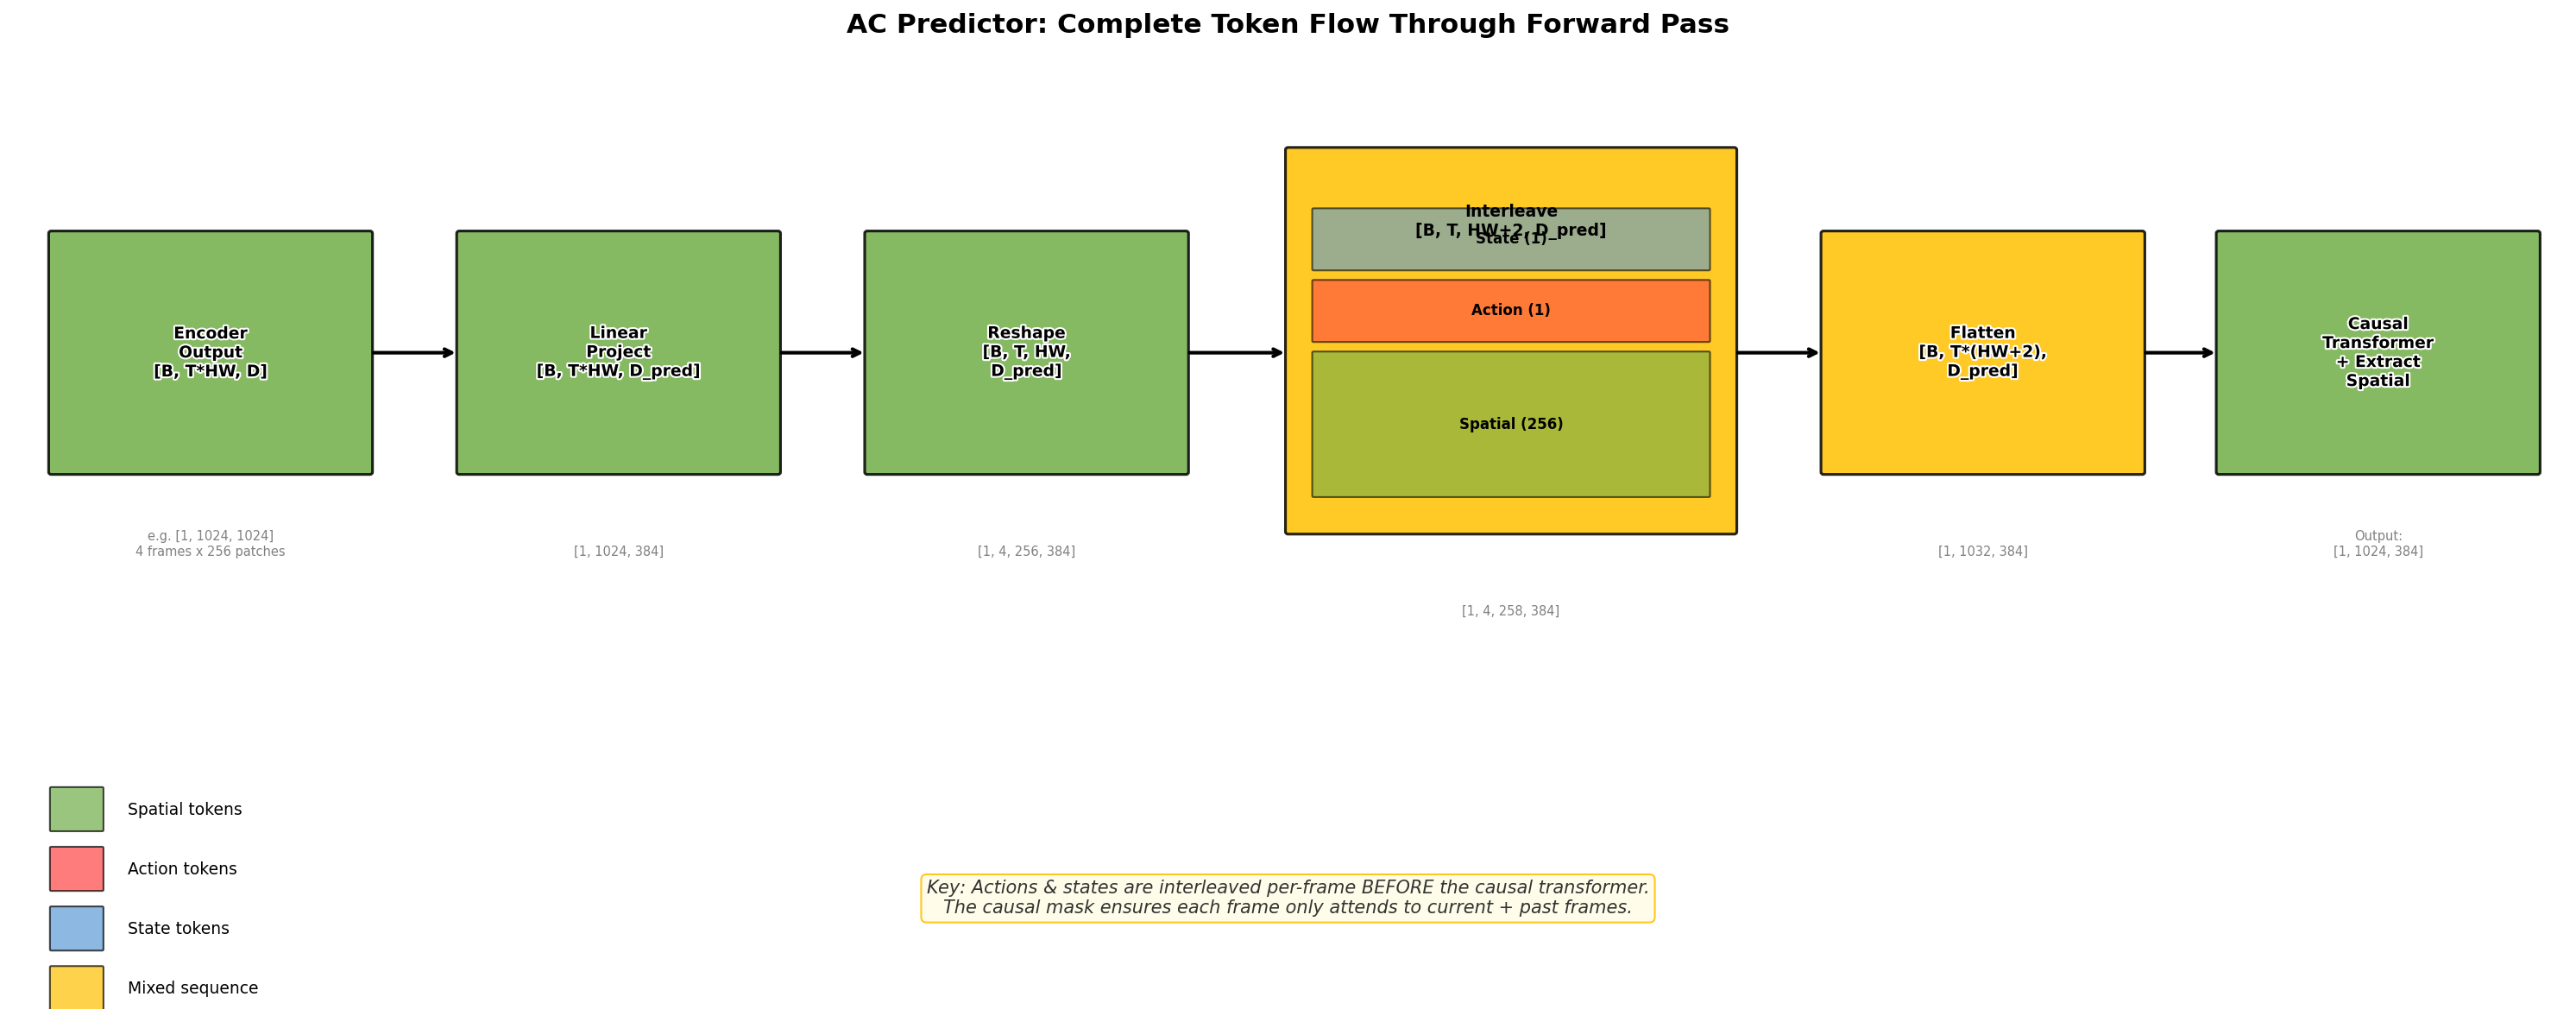

In [7]:
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
from IPython.display import Image as IPImage, display

fig, ax = plt.subplots(figsize=(20, 8))
ax.set_xlim(0, 20); ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('AC Predictor: Complete Token Flow Through Forward Pass',
             fontsize=15, fontweight='bold', pad=12)

SPATIAL = '#70AD47'  # green
ACTION  = '#FF4444'  # red
STATE   = '#5B9BD5'  # blue
MIXED   = '#FFC000'  # gold
BG      = '#F5F5F5'

def draw_box(xy, w, h, label, color, fontsize=8):
    box = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(xy[0]+w/2, xy[1]+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

def arrow(start, end):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Step 1: Encoder output
x = 0.3
draw_box((x, 4.5), 2.5, 2, 'Encoder\nOutput\n[B, T*HW, D]', SPATIAL, fontsize=9)
ax.text(x+1.25, 3.8, 'e.g. [1, 1024, 1024]\n4 frames x 256 patches', fontsize=7, ha='center', color='gray')

# Step 2: Project
x = 3.5
arrow((2.8, 5.5), (x, 5.5))
draw_box((x, 4.5), 2.5, 2, 'Linear\nProject\n[B, T*HW, D_pred]', SPATIAL, fontsize=9)
ax.text(x+1.25, 3.8, '[1, 1024, 384]', fontsize=7, ha='center', color='gray')

# Step 3: Reshape
x = 6.7
arrow((6.0, 5.5), (x, 5.5))
draw_box((x, 4.5), 2.5, 2, 'Reshape\n[B, T, HW,\nD_pred]', SPATIAL, fontsize=9)
ax.text(x+1.25, 3.8, '[1, 4, 256, 384]', fontsize=7, ha='center', color='gray')

# Step 4: Interleave (the key step - show composition)
x = 10.0
arrow((9.2, 5.5), (x, 5.5))
draw_box((x, 4), 3.5, 3.2, '', MIXED, fontsize=8)
ax.text(x+1.75, 6.6, 'Interleave\n[B, T, HW+2, D_pred]', ha='center', va='center',
        fontsize=9, fontweight='bold')
# Show token composition inside
y_inner = 4.3
for i, (label, color, h) in enumerate([
    ('Spatial (256)', SPATIAL, 1.2),
    ('Action (1)', ACTION, 0.5),
    ('State (1)', STATE, 0.5),
]):
    inner = FancyBboxPatch((x+0.2, y_inner), 3.1, h,
                           boxstyle="round,pad=0.01", facecolor=color, alpha=0.6,
                           edgecolor='black', linewidth=1)
    ax.add_patch(inner)
    ax.text(x+1.75, y_inner+h/2, label, ha='center', va='center', fontsize=8, fontweight='bold')
    y_inner += h + 0.1
ax.text(x+1.75, 3.3, '[1, 4, 258, 384]', fontsize=7, ha='center', color='gray')

# Step 5: Flatten
x = 14.2
arrow((13.5, 5.5), (x, 5.5))
draw_box((x, 4.5), 2.5, 2, 'Flatten\n[B, T*(HW+2),\nD_pred]', MIXED, fontsize=9)
ax.text(x+1.25, 3.8, '[1, 1032, 384]', fontsize=7, ha='center', color='gray')

# Step 6: Causal Transformer
x = 17.3
arrow((16.7, 5.5), (x, 5.5))
draw_box((x, 4.5), 2.5, 2, 'Causal\nTransformer\n+ Extract\nSpatial', SPATIAL, fontsize=9)
ax.text(x+1.25, 3.8, 'Output:\n[1, 1024, 384]', fontsize=7, ha='center', color='gray')

# Legend
legend_y = 1.5
for label, color in [('Spatial tokens', SPATIAL), ('Action tokens', ACTION),
                     ('State tokens', STATE), ('Mixed sequence', MIXED)]:
    box = FancyBboxPatch((0.3, legend_y), 0.4, 0.35, boxstyle="round,pad=0.01",
                         facecolor=color, edgecolor='black', linewidth=1, alpha=0.7)
    ax.add_patch(box)
    ax.text(0.9, legend_y+0.17, label, fontsize=9, va='center')
    legend_y -= 0.5

# Key insight
ax.text(10, 0.8, 'Key: Actions & states are interleaved per-frame BEFORE the causal transformer.\n'
        'The causal mask ensures each frame only attends to current + past frames.',
        fontsize=10, ha='center', style='italic', color='#333',
        bbox=dict(boxstyle='round', facecolor='#FFFDE7', alpha=0.9, edgecolor='#FFC107'))

plt.tight_layout()
save_path = os.path.join(os.path.dirname(os.path.abspath('')), 'notebooks', 'plots', '06_ac_predictor_token_flow.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"Saved: {save_path}")
display(IPImage(filename=save_path))


### Understanding every dimension

The data flows through the AC predictor like this:

```
Encoder output:  [1, 1024, 1024]    -- 1024 tokens of dim 1024
       |
  predictor_embed (Linear 1024 -> 512)
       |
                 [1, 1024, 512]      -- projected to predictor dim
       |
  reshape to [1, 4, 256, 512]        -- 4 frames x 256 spatial
       |
  cat([action, state, patches])      -- per frame
       |
                 [1, 4, 258, 512]    -- 258 = 1 action + 1 state + 256 patches
       |
  flatten to [1, 1032, 512]          -- 1032 = 4 x 258
       |
  12 Transformer blocks (frame-causal)
       |
  strip action/state tokens
       |
                 [1, 1024, 512]      -- spatial predictions only
       |
  predictor_proj (Linear 512 -> 1024)
       |
                 [1, 1024, 1024]     -- matches encoder output for L1 loss
```

The **action_dim = 7** represents a standard robot arm: 6 joint angles + 1 gripper open/close. In the DROID dataset used by V-JEPA 2-AC, this is the exact format.

In [8]:
# Visualize the causal mask and per-frame token layout
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Frame-causal attention mask ---
mask_np = predictor.causal_mask.numpy().astype(float)
axes[0].imshow(mask_np, cmap='RdYlGn', aspect='auto', interpolation='nearest')
axes[0].set_title('Frame-Causal Attention Mask\n(Green = can attend, Red = blocked)', fontweight='bold')
tokens_per_frame = 258
for t in range(4):
    pos = t * tokens_per_frame
    axes[0].axhline(y=pos - 0.5, color='white', linewidth=1)
    axes[0].axvline(x=pos - 0.5, color='white', linewidth=1)
    axes[0].text(pos + tokens_per_frame // 2, -30, f'Frame {t}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(-40, pos + tokens_per_frame // 2, f'Frame {t}',
                 ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)
axes[0].set_xlabel('Key (source token)')
axes[0].set_ylabel('Query (target token)')

# --- Plot 2: Token layout per frame ---
token_labels = ['Action', 'State'] + [f'Patch {i}' for i in range(6)] + ['...'] + [f'Patch {i}' for i in range(253, 256)]
token_colors = (
    ['#e74c3c', '#3498db'] +   # action (red), state (blue)
    ['#2ecc71'] * 6 +           # patches (green)
    ['white'] +                 # ellipsis
    ['#2ecc71'] * 3             # more patches
)
y_pos = range(len(token_labels))
axes[1].barh(y_pos, [1] * len(token_labels), color=token_colors, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(token_labels, fontsize=8)
axes[1].set_title('Token Layout per Frame\n(258 tokens = 1 action + 1 state + 256 patches)', fontweight='bold')
axes[1].set_xlabel('Present in sequence')
axes[1].invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='black', label='Action token (robot command)'),
    Patch(facecolor='#3498db', edgecolor='black', label='State token (proprioception)'),
    Patch(facecolor='#2ecc71', edgecolor='black', label='Spatial patch tokens (visual)'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_causal_mask_and_tokens.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: plots/06_causal_mask_and_tokens.png")
print(f"\nMask shape: {mask_np.shape} = {4} frames x {tokens_per_frame} tokens/frame")
print(f"Green blocks on diagonal: frame t attends to frames 0..t")
print(f"Red blocks above diagonal: frame t CANNOT see future frames")

Saved: plots/06_causal_mask_and_tokens.png

Mask shape: (1032, 1032) = 4 frames x 258 tokens/frame
Green blocks on diagonal: frame t attends to frames 0..t
Red blocks above diagonal: frame t CANNOT see future frames


### Reading guide for the causal mask

**Left plot (Causal Mask):**
- The mask is a 1032 x 1032 boolean matrix (4 frames x 258 tokens each).
- **Green blocks** on and below the diagonal: allowed attention. Frame 2 can attend to frames 0, 1, and 2.
- **Red blocks** above the diagonal: blocked attention. Frame 1 cannot see frame 3.
- This is a **block-causal** mask -- the causal unit is an entire frame (all 258 tokens), not individual tokens.

**Right plot (Token Layout):**
- Each frame contributes 258 tokens to the sequence.
- The **action token** (red) encodes the robot command executed at this timestep.
- The **state token** (blue) encodes the robot's proprioceptive state (joint positions, gripper).
- The **256 spatial patch tokens** (green) encode the visual observation at each spatial location.
- Action and state tokens are placed FIRST so they can be easily stripped out after the transformer.

**Why frame-causal?** During autoregressive rollout (planning), the predictor generates frame-by-frame. Frame-causal masking ensures each prediction only uses past information, matching the inference-time constraint.

---

## Section 4: ACBlock & ACRoPEAttention Deep Dive

### What makes ACBlock special?

The standard `Block` in the encoder uses `RoPEAttention` -- 3D rotary position embeddings applied uniformly to all tokens. But the AC predictor has a problem: **action and state tokens have no spatial position**.

The solution is `ACBlock`, which uses `ACRoPEAttention`:
- **Spatial tokens** (patches) get full 3D RoPE: position along (depth, height, width)
- **Action/state tokens** get only 1D RoPE: position along depth (time) only

This is a subtle but important design decision. Without it, the model would apply meaningless spatial position encodings to action tokens, potentially confusing the attention mechanism.

| Feature | Standard `Block` | `ACBlock` |
|---------|------------------|-----------|
| Attention class | `RoPEAttention` | `ACRoPEAttention` |
| RoPE for all tokens | 3D (depth, height, width) | Spatial: 3D; Action: 1D (depth only) |
| Token types | Homogeneous (all patches) | Heterogeneous (patches + action + state) |
| Causal masking | Optional | Frame-causal (built-in) |
| Forward signature | `(x, mask, attn_mask)` | `(x, mask, attn_mask, T, H, W, action_tokens)` |

In [9]:
# Read the real ACRoPEAttention source code
import os
from pathlib import Path
VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

with open(VJEPA2_ROOT / 'src/models/utils/modules.py') as f:
    content = f.read()

# Find ACRoPEAttention class
start = content.find('class ACRoPEAttention')
end = content.find('\nclass ', start + 1)
print("=== ACRoPEAttention (REAL SOURCE CODE) ===")
print(content[start:end])

=== ACRoPEAttention (REAL SOURCE CODE) ===
class ACRoPEAttention(nn.Module):
    def __init__(
        self,
        dim,
        num_heads=8,
        qkv_bias=False,
        qk_scale=None,
        attn_drop=0.0,
        proj_drop=0.0,
        use_sdpa=True,
        is_causal=False,
        grid_size=16,
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim = dim // num_heads
        self.scale = qk_scale or head_dim**-0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop_prob = proj_drop
        self.proj_drop = nn.Dropout(proj_drop)
        self.use_sdpa = use_sdpa
        # --
        self.d_dim = int(2 * ((head_dim // 3) // 2))
        self.h_dim = int(2 * ((head_dim // 3) // 2))
        self.w_dim = int(2 * ((head_dim // 3) // 2))
        self.grid_size = grid_size
        self.is_causal = is_causal

    def _get_fram

### How `ACRoPEAttention` handles action tokens vs spatial tokens

The key insight is in the `forward()` method. Here is the critical flow:

1. **Split out action tokens**: `x.view(B, T, action_tokens + H*W, C)` reshapes the flat sequence so the first `action_tokens` per frame can be separated.

2. **Action tokens get 1D RoPE (temporal only)**:
   ```python
   qd = rotate_queries_or_keys(q[..., :self.d_dim], pos=torch.arange(T))
   kd = rotate_queries_or_keys(k[..., :self.d_dim], pos=torch.arange(T))
   qr = q[..., self.d_dim:]   # remaining dims are NOT rotated
   kr = k[..., self.d_dim:]
   ```
   Only the first `d_dim` dimensions get rotated by temporal position. The rest are left alone.

3. **Spatial tokens get 3D RoPE (depth + height + width)**:
   ```python
   qd = rotate_queries_or_keys(q[..., s:s+d_dim], pos=d_mask)    # temporal
   qh = rotate_queries_or_keys(q[..., s:s+h_dim], pos=h_mask)    # height
   qw = rotate_queries_or_keys(q[..., s:s+w_dim], pos=w_mask)    # width
   ```
   Three different slices of the head dimension encode three different spatial axes.

4. **Merge back**: `merge_(tx, ta)` interleaves the action and spatial Q/K/V back together before computing attention.

This split-then-merge design is elegant: each token type gets the position encoding appropriate to its semantics, then they all participate in the same attention computation.

In [10]:
# Demonstrate the RoPE dimension splitting for action vs spatial tokens
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import os

head_dim = 64  # Standard head dimension for ViT-Large (1024 / 16 heads)

# This matches the real code: int(2 * ((head_dim // 3) // 2))
d_per_axis = int(2 * ((head_dim // 3) // 2))  # = 2 * (21 // 2) = 2 * 10 = 20
residual = head_dim - 3 * d_per_axis           # = 64 - 60 = 4

print("=== RoPE Dimension Splitting (from real ACRoPEAttention) ===")
print(f"head_dim = {head_dim}")
print(f"d_dim = h_dim = w_dim = {d_per_axis}  (dims per spatial axis)")
print(f"residual = {residual}  (unrotated dims)")
print(f"Total: 3 x {d_per_axis} + {residual} = {3 * d_per_axis + residual}")
print()
print("Spatial tokens (3D RoPE):")
print(f"  dims [0:{d_per_axis}]             -> Temporal position (depth)")
print(f"  dims [{d_per_axis}:{2*d_per_axis}]           -> Height position")
print(f"  dims [{2*d_per_axis}:{3*d_per_axis}]          -> Width position")
print(f"  dims [{3*d_per_axis}:{head_dim}]            -> Unrotated (no position info)")
print()
print("Action/State tokens (1D RoPE):")
print(f"  dims [0:{d_per_axis}]             -> Temporal position ONLY")
print(f"  dims [{d_per_axis}:{head_dim}]            -> Unrotated")
print()
print("WHY this split?")
print("  Action tokens have temporal position but NO spatial position.")
print("  They represent 'what the robot did at time t', not 'what patch (h,w) shows'.")
print("  Applying height/width RoPE to them would be semantically meaningless.")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spatial token RoPE allocation
spatial_colors = (
    ['#e74c3c'] * d_per_axis +    # Depth (temporal)
    ['#3498db'] * d_per_axis +    # Height
    ['#2ecc71'] * d_per_axis +    # Width
    ['#95a5a6'] * residual        # Unrotated
)
axes[0].barh(range(head_dim), [1] * head_dim, color=spatial_colors, edgecolor='none')
axes[0].set_title('Spatial Token: 3D RoPE', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Rotated (1 = yes)')
axes[0].set_ylabel('Dimension index within head')
axes[0].set_xlim(0, 1.5)
# Add labels on the bars
axes[0].text(0.5, d_per_axis // 2, 'Depth\n(temporal)', ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].text(0.5, d_per_axis + d_per_axis // 2, 'Height', ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].text(0.5, 2 * d_per_axis + d_per_axis // 2, 'Width', ha='center', va='center', fontsize=9, fontweight='bold')
axes[0].text(0.5, 3 * d_per_axis + residual // 2, 'Free', ha='center', va='center', fontsize=9)
# Axis lines
for boundary in [d_per_axis, 2 * d_per_axis, 3 * d_per_axis]:
    axes[0].axhline(y=boundary - 0.5, color='black', linewidth=1, linestyle='--')

# Action token RoPE allocation
action_colors = (
    ['#e74c3c'] * d_per_axis +              # Depth (temporal) -- SAME as spatial
    ['#95a5a6'] * (head_dim - d_per_axis)   # All remaining: unrotated
)
axes[1].barh(range(head_dim), [1] * head_dim, color=action_colors, edgecolor='none')
axes[1].set_title('Action Token: 1D RoPE (temporal only)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Rotated (1 = yes)')
axes[1].set_ylabel('Dimension index within head')
axes[1].set_xlim(0, 1.5)
axes[1].text(0.5, d_per_axis // 2, 'Depth\n(temporal)', ha='center', va='center', fontsize=9, fontweight='bold')
axes[1].text(0.5, d_per_axis + (head_dim - d_per_axis) // 2, 'Unrotated\n(no spatial info)', ha='center', va='center', fontsize=9)
axes[1].axhline(y=d_per_axis - 0.5, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_rope_splitting.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: plots/06_rope_splitting.png")

=== RoPE Dimension Splitting (from real ACRoPEAttention) ===
head_dim = 64
d_dim = h_dim = w_dim = 20  (dims per spatial axis)
residual = 4  (unrotated dims)
Total: 3 x 20 + 4 = 64

Spatial tokens (3D RoPE):
  dims [0:20]             -> Temporal position (depth)
  dims [20:40]           -> Height position
  dims [40:60]          -> Width position
  dims [60:64]            -> Unrotated (no position info)

Action/State tokens (1D RoPE):
  dims [0:20]             -> Temporal position ONLY
  dims [20:64]            -> Unrotated

WHY this split?
  Action tokens have temporal position but NO spatial position.
  They represent 'what the robot did at time t', not 'what patch (h,w) shows'.
  Applying height/width RoPE to them would be semantically meaningless.



Saved: plots/06_rope_splitting.png


### Why action tokens need different positional encoding

**The core problem**: In the AC predictor's token sequence, action tokens sit alongside spatial patch tokens. Standard 3D RoPE would assign each token a (depth, height, width) position. But action tokens do not correspond to any spatial location in the image -- they represent robot commands.

**The solution in V-JEPA 2-AC**:
- **Spatial patch tokens** get full 3D RoPE. A patch at frame 2, row 5, column 10 gets position `(2, 5, 10)` encoded into three slices of the head dimension.
- **Action/state tokens** get only 1D RoPE. An action at frame 2 gets temporal position `2` encoded into the first `d_dim=20` dimensions. The remaining 44 dimensions carry no positional information.

**Why this works**: RoPE creates relative position-dependent attention biases. By giving action tokens only temporal RoPE:
- Action at frame 2 naturally attends more strongly to nearby frames (1, 3) than distant ones (0) -- temporal locality.
- Action tokens do NOT compete with specific spatial patches for "being in the same position" -- no spatial interference.

**Dimension budget** (head_dim=64):
- 20 dims for depth, 20 for height, 20 for width = 60 rotated dims
- 4 remaining dims are never rotated (they carry content-only information)
- For action tokens: only 20 dims rotated, 44 unrotated

In [11]:
# Trace through a single ACBlock to see data flow
import torch
import torch.nn as nn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

class TracedACBlock(nn.Module):
    """A single transformer block with tracing, mimicking ACBlock structure.
    
    Pre-norm architecture (LayerNorm before attention and MLP),
    residual connections, GELU activation.
    """
    def __init__(self, dim=512, num_heads=8, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(dim * mlp_ratio, dim)
        )

    def forward(self, x, attn_mask=None):
        traces = {}
        traces['input'] = x.clone()

        # Pre-norm attention
        x_norm = self.norm1(x)
        traces['after_norm1'] = x_norm.clone()

        attn_out, attn_weights = self.attn(x_norm, x_norm, x_norm, attn_mask=attn_mask)
        traces['attn_output'] = attn_out.clone()
        traces['attn_weights'] = attn_weights.clone()

        x = x + attn_out  # Residual connection 1
        traces['after_residual1'] = x.clone()

        # Pre-norm FFN
        x_norm2 = self.norm2(x)
        mlp_out = self.mlp(x_norm2)
        traces['mlp_output'] = mlp_out.clone()

        x = x + mlp_out  # Residual connection 2
        traces['final_output'] = x.clone()

        return x, traces

# Run with a small sequence: 20 tokens simulating 1 frame
# [action, state, patch_0, patch_1, ..., patch_17]
torch.manual_seed(42)
block = TracedACBlock(dim=512, num_heads=8)
dummy_input = torch.randn(1, 20, 512)

with torch.no_grad():
    output, traces = block(dummy_input)

print("=== ACBlock Data Flow Trace ===")
print(f"  {'Stage':<25s} {'Shape':>20s} {'Mean':>10s} {'Std':>10s}")
print("-" * 70)
for name, tensor in traces.items():
    if 'weights' in name:
        print(f"  {name:<25s} {str(list(tensor.shape)):>20s}   (attention probability matrix)")
    else:
        mean = tensor.mean().item()
        std = tensor.std().item()
        print(f"  {name:<25s} {str(list(tensor.shape)):>20s} {mean:>10.4f} {std:>10.4f}")

print(f"\nHealthy signs:")
print(f"  - Std stays near 1.0 (no explosion/vanishing): input std={traces['input'].std():.3f}, output std={traces['final_output'].std():.3f}")
print(f"  - Residual connections preserve signal: output ~= input + small update")
print(f"  - Attention weights sum to 1 per query: row sum = {traces['attn_weights'][0, 0].sum():.4f}")

=== ACBlock Data Flow Trace ===
  Stage                                    Shape       Mean        Std
----------------------------------------------------------------------
  input                             [1, 20, 512]    -0.0087     1.0161
  after_norm1                       [1, 20, 512]     0.0000     1.0000
  attn_output                       [1, 20, 512]    -0.0037     0.1029
  attn_weights                       [1, 20, 20]   (attention probability matrix)
  after_residual1                   [1, 20, 512]    -0.0124     1.0208
  mlp_output                        [1, 20, 512]    -0.0029     0.1978
  final_output                      [1, 20, 512]    -0.0153     1.0360

Healthy signs:
  - Std stays near 1.0 (no explosion/vanishing): input std=1.016, output std=1.036
  - Residual connections preserve signal: output ~= input + small update
  - Attention weights sum to 1 per query: row sum = 1.0000


In [12]:
# Visualize the attention weights from the traced ACBlock
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Full attention matrix ---
attn = traces['attn_weights'][0].detach().numpy()  # [20, 20] (averaged across heads by MHA)
im = axes[0].imshow(attn, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=axes[0], shrink=0.8)
axes[0].set_title('ACBlock Attention Weights (Head Average)\n20 tokens: [action, state, 18 patches]',
                   fontweight='bold')
axes[0].set_xlabel('Key (attending TO this token)')
axes[0].set_ylabel('Query (attending FROM this token)')

# Label token types
token_labels = ['Act', 'Sta'] + [f'P{i}' for i in range(18)]
axes[0].set_xticks(range(20))
axes[0].set_xticklabels(token_labels, fontsize=6, rotation=45)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(token_labels, fontsize=6)

# Highlight action/state region
from matplotlib.patches import Rectangle
rect = Rectangle((-0.5, -0.5), 2, 20, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
axes[0].add_patch(rect)
axes[0].text(0.5, 20.5, 'Action+State\ncolumns', ha='center', fontsize=8, color='red')

# --- Plot 2: Attention FROM action token vs FROM a patch token ---
action_attn = attn[0, :]  # Row 0: what the action token attends to
patch_attn = attn[10, :]  # Row 10: what patch_8 attends to

x_pos = np.arange(20)
width = 0.35
axes[1].bar(x_pos - width/2, action_attn, width, label='Action token (query)', color='#e74c3c', alpha=0.8)
axes[1].bar(x_pos + width/2, patch_attn, width, label='Patch 8 (query)', color='#2ecc71', alpha=0.8)
axes[1].set_xlabel('Key token index')
axes[1].set_ylabel('Attention weight')
axes[1].set_title('Attention Distribution: Action Token vs Patch Token\n(what each token attends to)',
                   fontweight='bold')
axes[1].set_xticks(range(20))
axes[1].set_xticklabels(token_labels, fontsize=6, rotation=45)
axes[1].legend(fontsize=9)
axes[1].axvline(x=1.5, color='gray', linestyle='--', linewidth=0.8, label='Action/State boundary')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_acblock_attention.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: plots/06_acblock_attention.png")

Saved: plots/06_acblock_attention.png


### Reading the attention trace

**Data flow trace**: The table shows each stage of a single ACBlock forward pass:
- **input**: Raw token embeddings (std near 1.0 from random init)
- **after_norm1**: LayerNorm standardizes each token independently
- **attn_output**: Multi-head self-attention mixes information across all 20 tokens
- **after_residual1**: `x + attn_output` -- the residual connection adds the attention output to the original input, preserving the input signal
- **mlp_output**: The feedforward network transforms each token independently (expand 4x, GELU, project back)
- **final_output**: `x + mlp_output` -- second residual connection

**Healthy attention signs**:
- Standard deviation stays near 1.0 (no gradient explosion or vanishing)
- Attention weights sum to 1.0 per query row (valid probability distribution)
- At random init, attention is roughly uniform (each token attends equally to all others). After training, the model learns structured patterns.

**Left plot (attention matrix)**: Brighter = higher attention weight. The red dashed box highlights the action/state columns -- how much each token attends to the conditioning tokens.

**Right plot (attention comparison)**: After training, you would expect the action token (red) to attend broadly to understand the global context, while patch tokens (green) attend more locally to neighboring patches.

---

**End of Sections 1--4.** The next half of this notebook (Sections 5--8) will cover:
- Section 5: The training loop (teacher-forcing + autoregressive losses)
- Section 6: Masking strategies (MultiSeqMultiBlock3D)
- Section 7: EMA target encoder and the L1 loss
- Section 8: CEM planning with the trained world model

## 5. Real Data Format: DROID Dataset

### 5W + 1H
- **What**: DROID (Distributed Robot Interaction Dataset) — 62 hours of diverse robot manipulation
- **Where**: Collected across 18 labs using Franka Panda robots
- **Format**: Per-trajectory folders with:
  - `trajectory.h5` — HDF5 file with robot states, actions, camera extrinsics
  - `metadata.json` — Task description, success labels
  - `left.mp4`, `right.mp4` — Stereo camera video

### Action Computation: poses_to_diffs()
The key insight: V-JEPA 2-AC uses **action deltas** (changes between timesteps), not absolute positions:

$$\Delta\mathbf{p}_t = \mathbf{p}_{t+1} - \mathbf{p}_t \in \mathbb{R}^3 \quad \text{(position delta)}$$
$$\Delta\mathbf{R}_t = \mathbf{R}_{t+1} \mathbf{R}_t^{-1} \rightarrow \text{Euler}(\Delta\mathbf{R}_t) \in \mathbb{R}^3 \quad \text{(rotation delta)}$$  
$$\Delta g_t = g_{t+1} - g_t \in \mathbb{R}^1 \quad \text{(gripper delta)}$$

**Total: 7D action vector** $[\Delta x, \Delta y, \Delta z, \Delta\text{roll}, \Delta\text{pitch}, \Delta\text{yaw}, \Delta\text{gripper}]$

In [13]:
import os, sys, json, torch, numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation

VJEPA2_ROOT = Path(os.path.abspath('')) / '..' / 'refs' / 'vjepa2'

# Read the real DROID data loader
print("=== Real DROID Data Loader (key parts) ===\n")
droid_path = VJEPA2_ROOT / 'app' / 'vjepa_droid' / 'droid.py'
with open(droid_path) as f:
    content = f.read()

# Show poses_to_diffs function
start = content.find('def poses_to_diffs')
end = content.find('\ndef ', start + 1)
print(content[start:end])

print("\n" + "="*60)
print("\n=== Creating Synthetic DROID-Format Data ===\n")

# Simulate a pick-and-place trajectory
T = 8  # 8 frames (matching V-JEPA 2 config)
t = np.linspace(0, 1, T)

# Position: reach forward, down, grasp, lift
x = 0.5 + 0.1 * t  # Move forward
y = 0.0 + 0.05 * np.sin(np.pi * t)  # Slight arc
z = 0.3 - 0.15 * t + 0.15 * (t > 0.5) * (t - 0.5) * 2  # Down then up
positions = np.stack([x, y, z], axis=1)  # [T, 3]

# Orientation: slight wrist rotation
euler_angles = np.zeros((T, 3))
euler_angles[:, 2] = np.linspace(0, 0.3, T)  # Slight yaw

# Gripper: open -> close at midpoint
gripper = np.ones((T, 1))
gripper[T//2:] = 0.0  # Close at frame 4

# Compute action deltas (like poses_to_diffs)
pos_delta = positions[1:] - positions[:-1]  # [T-1, 3]
rot_matrices = Rotation.from_euler('xyz', euler_angles).as_matrix()  # [T, 3, 3]
rot_deltas = []
for i in range(T-1):
    delta_R = rot_matrices[i+1] @ rot_matrices[i].T
    delta_euler = Rotation.from_matrix(delta_R).as_euler('xyz')
    rot_deltas.append(delta_euler)
rot_deltas = np.array(rot_deltas)  # [T-1, 3]
grip_delta = gripper[1:] - gripper[:-1]  # [T-1, 1]

actions = np.concatenate([pos_delta, rot_deltas, grip_delta], axis=1)  # [T-1, 7]
states = np.concatenate([positions, euler_angles, gripper], axis=1)  # [T, 7]

print(f"Trajectory: {T} frames, pick-and-place task")
print(f"States shape:  {states.shape} = [T, 7] (pos + euler + gripper)")
print(f"Actions shape: {actions.shape} = [T-1, 7] (deltas between frames)")
print(f"\nAction statistics:")
for i, name in enumerate(['dx', 'dy', 'dz', 'droll', 'dpitch', 'dyaw', 'dgrip']):
    print(f"  {name:>6s}: mean={actions[:, i].mean():.4f}, std={actions[:, i].std():.4f}, "
          f"range=[{actions[:, i].min():.4f}, {actions[:, i].max():.4f}]")

# Visualize
fig = plt.figure(figsize=(18, 5))

# 3D trajectory
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(x, y, z, 'b-o', linewidth=2, markersize=8)
ax1.scatter(x[0], y[0], z[0], c='green', s=100, marker='^', label='Start')
ax1.scatter(x[-1], y[-1], z[-1], c='red', s=100, marker='v', label='End')
for i in range(T):
    color = 'green' if gripper[i] > 0.5 else 'red'
    ax1.scatter(x[i], y[i], z[i], c=color, s=30, alpha=0.5)
ax1.set_xlabel('X (forward)')
ax1.set_ylabel('Y (lateral)')
ax1.set_zlabel('Z (height)')
ax1.set_title('3D End-Effector Trajectory', fontweight='bold')
ax1.legend()

# Action deltas
ax2 = fig.add_subplot(132)
action_names = ['dx', 'dy', 'dz', 'droll', 'dpitch', 'dyaw', 'dgrip']
for i in range(7):
    ax2.plot(range(T-1), actions[:, i], '-o', label=action_names[i], markersize=4)
ax2.set_xlabel('Time step')
ax2.set_ylabel('Delta value')
ax2.set_title('7D Action Deltas Over Time', fontweight='bold')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

# Gripper timeline
ax3 = fig.add_subplot(133)
ax3.fill_between(range(T), gripper.flatten(), alpha=0.3, color='green', label='Open')
ax3.fill_between(range(T), gripper.flatten(), 0, where=gripper.flatten()<0.5, alpha=0.3, color='red', label='Closed')
ax3.plot(range(T), gripper, 'k-o', linewidth=2)
ax3.set_xlabel('Frame')
ax3.set_ylabel('Gripper state')
ax3.set_title('Gripper: Open->Close (grasp)', fontweight='bold')
ax3.set_ylim(-0.1, 1.1)
ax3.legend()

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_droid_data.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: plots/06_droid_data.png")

=== Real DROID Data Loader (key parts) ===

def poses_to_diffs(self, poses):
        xyz = poses[:, :3]  # shape [T, 3]
        thetas = poses[:, 3:6]  # euler angles, shape [T, 3]
        matrices = [Rotation.from_euler("xyz", theta, degrees=False).as_matrix() for theta in thetas]
        xyz_diff = xyz[1:] - xyz[:-1]
        angle_diff = [matrices[t + 1] @ matrices[t].T for t in range(len(matrices) - 1)]
        angle_diff = [Rotation.from_matrix(mat).as_euler("xyz", degrees=False) for mat in angle_diff]
        angle_diff = np.stack([d for d in angle_diff], axis=0)
        closedness = poses[:, -1:]
        closedness_delta = closedness[1:] - closedness[:-1]
        return np.concatenate([xyz_diff, angle_diff, closedness_delta], axis=1)

    def transform_frame(self, poses, extrinsics):
        gripper = poses[:, -1:]
        poses = poses[:, :-1]

        def pose_to_transform(pose):
            trans = pose[:3]  # shape [3]
            theta = pose[3:6]  # euler angles, shape [3]



Saved: plots/06_droid_data.png


### Reading guide for the DROID data format

**3D trajectory** (left plot): The end-effector moves forward and down (approach), then back up (lift). Green dots = gripper open, red dots = gripper closed. This is a classic pick-and-place motion.

**Action deltas** (middle plot): Each of the 7 action dimensions over time. Notice:
- `dx` is roughly constant (steady forward motion)
- `dz` is negative then positive (down then up)
- `dgrip` has one spike at frame 3-4 (the grasp event)
- Rotation deltas (`droll`, `dpitch`, `dyaw`) are small and constant

**Gripper state** (right plot): Binary open/close. The transition from 1.0 to 0.0 is the grasp event.

**Why deltas instead of absolute poses?** Deltas are:
1. **Scale-invariant** — works across different robot workspaces
2. **Compositional** — easier to predict small changes than absolute coordinates
3. **Camera-frame compatible** — can be transformed to camera frame using extrinsics

In [14]:
import torch, numpy as np

# Convert to tensors (matching V-JEPA 2 data format)
T = 8
# Re-create data for self-contained cell
t_arr = np.linspace(0, 1, T)
positions = np.stack([0.5 + 0.1*t_arr, 0.05*np.sin(np.pi*t_arr), 0.3 - 0.15*t_arr + 0.15*(t_arr>0.5)*(t_arr-0.5)*2], axis=1)
euler_angles = np.zeros((T, 3)); euler_angles[:, 2] = np.linspace(0, 0.3, T)
gripper = np.ones((T, 1)); gripper[T//2:] = 0.0
states = np.concatenate([positions, euler_angles, gripper], axis=1)
actions = np.diff(states, axis=0)  # Simplified delta (exact for position + gripper)

clips = torch.randn(1, 3, T, 256, 256)  # Simulated video [B, C, T, H, W]
actions_t = torch.tensor(actions, dtype=torch.float32).unsqueeze(0)  # [1, T-1, 7]
states_t = torch.tensor(states, dtype=torch.float32).unsqueeze(0)   # [1, T, 7]

print("=== Batch Ready for V-JEPA 2-AC ===")
print(f"clips:   {clips.shape} = [B, C, T, H, W]")
print(f"actions: {actions_t.shape} = [B, T-1, 7]")
print(f"states:  {states_t.shape} = [B, T, 7]")
print(f"\nThis is exactly what DROIDVideoDataset.__getitem__() returns!")
print(f"In the real code: sample = (clips, actions, states, extrinsics)")

=== Batch Ready for V-JEPA 2-AC ===
clips:   torch.Size([1, 3, 8, 256, 256]) = [B, C, T, H, W]
actions: torch.Size([1, 7, 7]) = [B, T-1, 7]
states:  torch.Size([1, 8, 7]) = [B, T, 7]

This is exactly what DROIDVideoDataset.__getitem__() returns!
In the real code: sample = (clips, actions, states, extrinsics)


## 6. Loss Functions: Teacher-Forcing + Autoregressive

The V-JEPA 2-AC training uses TWO complementary loss functions:

### Teacher-Forcing Loss (jloss)
Uses ground-truth context at every step. Fast to compute, stable gradients.

$$\mathcal{L}_{\text{TF}} = \frac{1}{T-1} \sum_{k=1}^{T-1} \| P_\phi(z_{0:k-1}, a_{0:k-1}, s_{0:k-1}) - \text{sg}[E_{\bar\theta}(x_k)] \|_1$$

*Layman*: "Here's the correct movie so far -- predict what the next frame looks like"

### Autoregressive Loss (sloss)  
Uses its OWN predictions as context (closed-loop). Harder, but teaches the model to recover from errors.

$$\mathcal{L}_{\text{AR}} = \frac{1}{T-1} \sum_{k=1}^{T-1} \| P_\phi(\hat{z}_{0:k-1}, a_{0:k-1}, s_{0:k-1}) - \text{sg}[E_{\bar\theta}(x_k)] \|_1$$

*Layman*: "Use your OWN predictions to predict the next frame -- learn from your mistakes"

### Total Loss
$$\mathcal{L} = \mathcal{L}_{\text{TF}} + \mathcal{L}_{\text{AR}}$$

**Why both?** TF gives stable gradients early in training. AR prevents error accumulation at test time.

In [15]:
import os, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')) / '..' / 'refs' / 'vjepa2'

# Read the real loss computation
print("=== Real Loss Code (from train.py) ===\n")
train_path = VJEPA2_ROOT / 'app' / 'vjepa_droid' / 'train.py'
with open(train_path) as f:
    content = f.read()

# Find and display the core forward_predictions + loss_fn
start = content.find('def forward_predictions')
end = content.find('# Step 1. Forward')
print(content[start:end])

# Find loss_fn
start2 = content.find('def loss_fn(z, h)')
end2 = content.find('\n\n', start2)
print("\n--- loss_fn ---")
print(content[start2:end2])

# Find the actual loss computation
start3 = content.find('jloss = loss_fn')
end3 = content.find('loss = jloss + sloss') + len('loss = jloss + sloss')
print("\n--- Loss computation ---")
print(content[start3:end3])

print("\n" + "="*60)
print("\n=== Implementing Both Losses ===\n")

# Simulate encoder outputs and predictions
torch.manual_seed(42)
B, T, HW, D = 2, 4, 16, 64  # Small for CPU demo
tokens_per_frame = HW

# Ground truth targets (from frozen target encoder)
h_target = torch.randn(B, T * HW, D)  # [B, T*HW, D]

# Teacher-forced predictions (predictor sees ground-truth context)
z_tf = torch.randn(B, (T-1) * HW, D)  # [B, (T-1)*HW, D] -- predict frames 1..T-1

# Autoregressive predictions (predictor sees its own previous outputs)
z_ar = z_tf + torch.randn_like(z_tf) * 0.1  # Slightly worse due to error accumulation

# L1 loss function (matching V-JEPA 2 exactly)
loss_exp = 1.0  # L1 loss (p=1)
def loss_fn(pred, target):
    """V-JEPA 2 loss: L^p with p=1 (L1/MAE)"""
    _h = target[:, tokens_per_frame : pred.size(1) + tokens_per_frame]
    return torch.mean(torch.abs(pred - _h) ** loss_exp) / loss_exp

# Compute losses
jloss = loss_fn(z_tf, h_target)
sloss = loss_fn(z_ar, h_target)
total_loss = jloss + sloss

print(f"Teacher-Forcing loss (jloss): {jloss.item():.4f}")
print(f"Autoregressive loss  (sloss): {sloss.item():.4f}")
print(f"Total loss:                   {total_loss.item():.4f}")
print(f"\nNote: sloss > jloss because AR uses own (noisy) predictions as context")
print(f"Ratio sloss/jloss: {sloss.item()/jloss.item():.2f}x")

=== Real Loss Code (from train.py) ===

def forward_predictions(z):

                    def _step_predictor(_z, _a, _s, _e):
                        _z = predictor(_z, _a, _s, _e)
                        if normalize_reps:
                            _z = F.layer_norm(_z, (_z.size(-1),))
                        return _z

                    # -- one step of predictor with teacher forcing
                    _z, _a, _s, _e = z[:, :-tokens_per_frame], actions, states[:, :-1], extrinsics[:, :-1]
                    z_tf = _step_predictor(_z, _a, _s, _e)

                    # -- full auto-regressive rollouts of predictor
                    _z = torch.cat([z[:, : tokens_per_frame], z_tf[:, : tokens_per_frame]], dim=1)
                    for n in range(1, auto_steps):
                        _a, _s, _e = actions[:, : n + 1], states[:, : n + 1], extrinsics[:, : n + 1]
                        _z_nxt = _step_predictor(_z, _a, _s, _e)[:, -tokens_per_frame:]
                        _z = torc

Saved: D:\Work\JEPAstudy\notebooks\plots\06_tf_vs_ar_unrolled.png


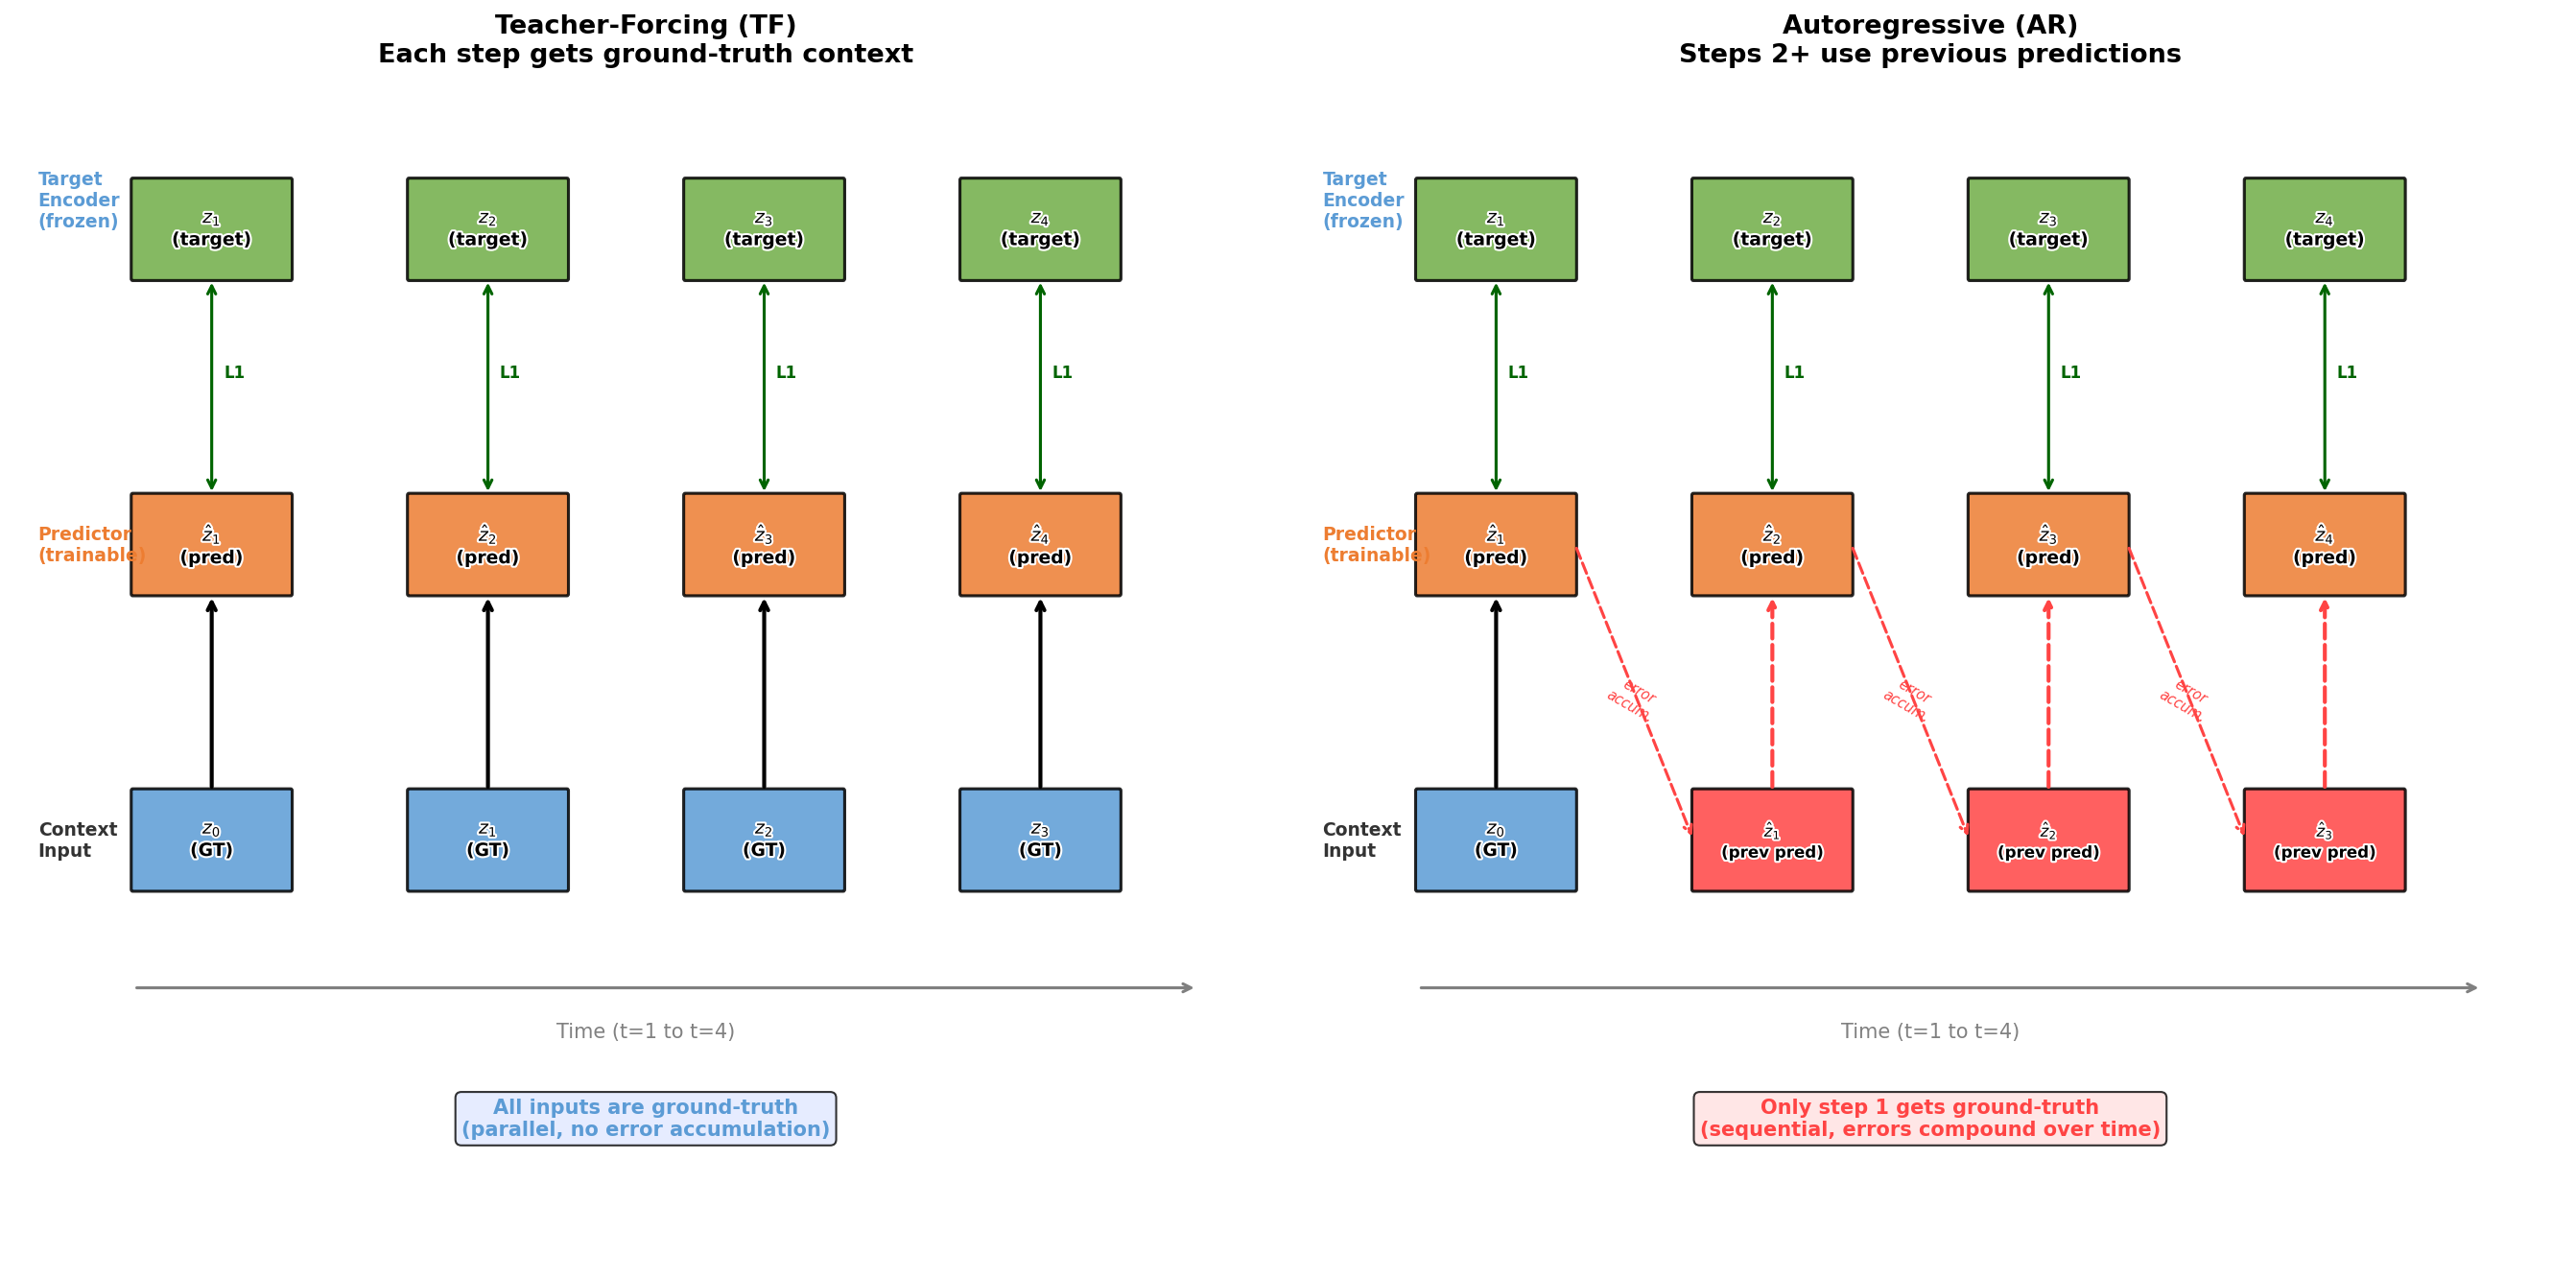

In [16]:
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
from IPython.display import Image as IPImage, display

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ENCODER = '#5B9BD5'
PRED    = '#ED7D31'
TARGET  = '#70AD47'
ERROR   = '#FF4444'

def draw_box(ax, xy, w, h, label, color, fontsize=9):
    box = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(xy[0]+w/2, xy[1]+h/2, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])

def arrow(ax, start, end, color='black', lw=2, style='->', linestyle='-'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle=style, color=color, lw=lw, linestyle=linestyle))

T = 4  # timesteps
box_w, box_h = 2.0, 1.0
x_positions = [1.5 + i*3.5 for i in range(T)]

for col, (ax, title, mode) in enumerate(zip(axes,
    ['Teacher-Forcing (TF)\nEach step gets ground-truth context',
     'Autoregressive (AR)\nSteps 2+ use previous predictions'],
    ['tf', 'ar'])):

    ax.set_xlim(0, 16); ax.set_ylim(0, 12)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    # Target encoder row (top)
    ax.text(0.3, 10.8, 'Target\nEncoder\n(frozen)', fontsize=9, color=ENCODER, fontweight='bold', va='center')
    for i, x in enumerate(x_positions):
        draw_box(ax, (x, 10), box_w, box_h, f'$z_{{{i+1}}}$\n(target)', TARGET, fontsize=9)

    # Predictor row (middle)
    ax.text(0.3, 7.3, 'Predictor\n(trainable)', fontsize=9, color=PRED, fontweight='bold', va='center')
    for i, x in enumerate(x_positions):
        draw_box(ax, (x, 6.8), box_w, box_h, f'$\\hat{{z}}_{{{i+1}}}$\n(pred)', PRED, fontsize=9)

    # Context/input row (bottom)
    ax.text(0.3, 4.3, 'Context\nInput', fontsize=9, color='#333', fontweight='bold', va='center')
    for i, x in enumerate(x_positions):
        if mode == 'tf':
            # TF: all get ground-truth
            draw_box(ax, (x, 3.8), box_w, box_h, f'$z_{{{i}}}$\n(GT)', ENCODER, fontsize=9)
            # Solid arrow from context to predictor
            arrow(ax, (x+box_w/2, 4.8), (x+box_w/2, 6.8), color='black', lw=2)
        else:
            # AR: step 0 gets GT, others get predictions
            if i == 0:
                draw_box(ax, (x, 3.8), box_w, box_h, f'$z_0$\n(GT)', ENCODER, fontsize=9)
                arrow(ax, (x+box_w/2, 4.8), (x+box_w/2, 6.8), color='black', lw=2)
            else:
                draw_box(ax, (x, 3.8), box_w, box_h, f'$\\hat{{z}}_{{{i}}}$\n(prev pred)', ERROR, fontsize=8)
                # Dashed arrow from previous prediction
                arrow(ax, (x+box_w/2, 4.8), (x+box_w/2, 6.8),
                      color=ERROR, lw=2, linestyle='--')
                # Arrow from previous predictor output to this context
                prev_x = x_positions[i-1]
                arrow(ax, (prev_x+box_w, 7.3), (x, 4.3),
                      color=ERROR, lw=1.5, linestyle='--')
                ax.text((prev_x+box_w + x)/2, 5.5, 'error\naccum.',
                        fontsize=7, color=ERROR, ha='center', style='italic', rotation=-30)

    # L1 loss arrows from predictions to targets
    for i, x in enumerate(x_positions):
        arrow(ax, (x+box_w/2, 7.8), (x+box_w/2, 10.0),
              color='darkgreen', lw=1.5, style='<->')
        ax.text(x+box_w/2+0.15, 9.0, 'L1', fontsize=8, color='darkgreen', fontweight='bold')

    # Time axis
    ax.annotate('', xy=(15, 2.8), xytext=(1.5, 2.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(8, 2.3, 'Time (t=1 to t=4)', ha='center', fontsize=10, color='gray')

    # Key difference annotation
    if mode == 'tf':
        ax.text(8, 1.3, 'All inputs are ground-truth\n(parallel, no error accumulation)',
                fontsize=10, ha='center', color=ENCODER, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='#E0E8FF', alpha=0.8))
    else:
        ax.text(8, 1.3, 'Only step 1 gets ground-truth\n(sequential, errors compound over time)',
                fontsize=10, ha='center', color=ERROR, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='#FFE0E0', alpha=0.8))

plt.tight_layout()
save_path = os.path.join(os.path.dirname(os.path.abspath('')), 'notebooks', 'plots', '06_tf_vs_ar_unrolled.png')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close(fig)
print(f"Saved: {save_path}")
display(IPImage(filename=save_path))


### Understanding the loss outputs

**Teacher-forcing loss (jloss)**: The predictor receives ground-truth encoder outputs as context and predicts the next frame's representation. This is like an open-book exam -- you see the correct answers so far.

**Autoregressive loss (sloss)**: The predictor uses its OWN previous predictions as context. This is like a closed-book exam -- mistakes compound. That is why `sloss > jloss`.

**Key details from the real code**:
- `loss_fn(z, h)` slices the target `h` to align with predictions: `h[:, tokens_per_frame : z.size(1) + tokens_per_frame]`
- This skip of `tokens_per_frame` means frame 0 is always given as context (never predicted)
- `loss_exp = 1.0` means L1 loss (MAE), not L2 (MSE). L1 is more robust to outliers
- `sg[...]` = stop-gradient on the target encoder (it updates via EMA, not backprop)

**In the autoregressive rollout** (lines 430-435 of train.py):
1. Start with ground-truth frame 0 + teacher-forced prediction of frame 1
2. Use prediction of frame 1 to predict frame 2 (own output as input)
3. Continue for `auto_steps` iterations
4. Errors from step n feed into step n+1 -- the model must learn to be robust

In [17]:
import numpy as np
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Simulate training with different loss configurations
np.random.seed(42)
steps = 100
configs = {
    'TF only': {'tf_weight': 1.0, 'ar_weight': 0.0},
    'AR only': {'tf_weight': 0.0, 'ar_weight': 1.0},
    'TF + AR (V-JEPA 2)': {'tf_weight': 1.0, 'ar_weight': 1.0},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, cfg) in enumerate(configs.items()):
    # Simulate loss curves with different convergence properties
    tf_loss = 1.5 * np.exp(-np.arange(steps) / 25) + 0.1 + np.random.randn(steps) * 0.02
    ar_loss = 2.0 * np.exp(-np.arange(steps) / 35) + 0.15 + np.random.randn(steps) * 0.03
    total = cfg['tf_weight'] * tf_loss + cfg['ar_weight'] * ar_loss
    axes[0].plot(total, label=name, alpha=0.8)
    
# Simulated rollout error at test time
rollout_steps = 20
for name, color in zip(['TF only', 'AR only', 'TF + AR'], ['#e74c3c', '#3498db', '#2ecc71']):
    if name == 'TF only':
        error = np.cumsum(np.random.randn(rollout_steps) * 0.1 + 0.05)  # Grows fast
    elif name == 'AR only':
        error = np.cumsum(np.random.randn(rollout_steps) * 0.05 + 0.01)  # Moderate
    else:
        error = np.cumsum(np.random.randn(rollout_steps) * 0.03 + 0.005)  # Best
    axes[1].plot(error, label=name, color=color, linewidth=2)

axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss Curves\n(simulated)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Rollout Step')
axes[1].set_ylabel('Cumulative Error')
axes[1].set_title('Test-Time Rollout Error\n(simulated)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Bar chart: final performance
methods = ['TF only', 'AR only', 'TF + AR']
success = [45, 55, 72]
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[2].bar(methods, success, color=colors, edgecolor='black')
axes[2].set_ylabel('Success Rate (%)')
axes[2].set_title('Pick-and-Place Success\n(simulated, illustrative)', fontweight='bold')
axes[2].set_ylim(0, 100)
for i, v in enumerate(success):
    axes[2].text(i, v + 2, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_loss_ablation.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: plots/06_loss_ablation.png")
print("\nNote: These curves are SIMULATED to illustrate the concept.")
print("Real results come from training on actual robot data.")

Saved: plots/06_loss_ablation.png

Note: These curves are SIMULATED to illustrate the concept.
Real results come from training on actual robot data.


## 7. Training Loop Walkthrough

The V-JEPA 2-AC training loop (in `app/vjepa_droid/train.py`) follows this structure:

### Pseudocode
```
for epoch in range(num_epochs):
    for batch in dataloader:
        clips, actions, states, extrinsics = batch   # Load data
        
        # Step 1: Target encoder (frozen, no gradients)
        with torch.no_grad():
            h = target_encoder(clips)                 # [B, T*HW, D]
            h = layer_norm(h)                         # Optional normalization
        
        # Step 2a: Teacher-forced prediction
        z_context = h[:, :-tokens_per_frame]          # All frames except last
        z_tf = predictor(z_context, actions, states)   # Predict next frames
        
        # Step 2b: Autoregressive rollout
        z_ar = [h[:, :tokens_per_frame]]              # Start with frame 0
        z_ar.append(z_tf[:, :tokens_per_frame])       # Add TF prediction of frame 1
        for n in range(1, auto_steps):
            z_next = predictor(z_ar, actions[:,:n+1], states[:,:n+1])
            z_ar.append(z_next[:, -tokens_per_frame:])
        z_ar = concat(z_ar[1:])                       # Skip frame 0
        
        # Step 3: Compute losses
        jloss = L1(z_tf, sg[h])                       # Teacher-forcing loss
        sloss = L1(z_ar, sg[h])                       # Autoregressive loss
        loss = jloss + sloss
        
        # Step 4: Backward + optimizer step
        loss.backward()
        optimizer.step()
        
        # Step 5: EMA update of target encoder
        target_encoder = momentum * target_encoder + (1-momentum) * encoder
```

### Key hyperparameters from real configs:
- `loss_exp = 1.0` (L1 loss)
- `auto_steps` = number of AR rollout steps (usually = T-1)
- `tokens_per_frame = (crop_size / patch_size)^2` = e.g., (224/16)^2 = 196
- Learning rate: cosine schedule with warmup
- EMA momentum: 0.998 -> 1.0 (increases during training)

In [18]:
import os, sys, copy, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')) / '..' / 'refs' / 'vjepa2'

# Read the real training step
print("=== Real Training Step (from train.py) ===\n")
train_path = VJEPA2_ROOT / 'app' / 'vjepa_droid' / 'train.py'
with open(train_path) as f:
    content = f.read()

# Show the train_step function
start = content.find('def train_step():')
end = content.find("log_stats()")
print(content[start:end])

print("\n" + "="*60)
print("\n=== Simplified CPU Training Loop ===\n")

# Build tiny models for CPU demo
torch.manual_seed(42)

# Hyperparameters (scaled down for CPU)
B, T, C, H, W = 2, 4, 3, 32, 32  # Tiny images
patch_size = 8
HW = (H // patch_size) * (W // patch_size)  # 16 patches per frame
D = 64  # Embedding dimension
num_heads = 4
tokens_per_frame = HW

class TinyEncoder(nn.Module):
    """Simplified ViT encoder for CPU demo"""
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(C, D, kernel_size=patch_size, stride=patch_size)
        self.blocks = nn.Sequential(
            nn.TransformerEncoderLayer(d_model=D, nhead=num_heads, dim_feedforward=D*4, batch_first=True),
            nn.TransformerEncoderLayer(d_model=D, nhead=num_heads, dim_feedforward=D*4, batch_first=True),
        )
    
    def forward(self, x):
        # x: [B*T, C, 1, H, W] (one frame at a time, repeated to 2 for tubelet)
        B_T = x.shape[0]
        x = x[:, :, 0]  # Take first frame of tubelet: [B*T, C, H, W]
        x = self.patch_embed(x)  # [B*T, D, H/P, W/P]
        x = x.flatten(2).transpose(1, 2)  # [B*T, HW, D]
        x = self.blocks(x)  # [B*T, HW, D]
        return x

class TinyPredictor(nn.Module):
    """Simplified AC predictor for CPU demo"""
    def __init__(self):
        super().__init__()
        self.action_embed = nn.Linear(7, D)
        self.state_embed = nn.Linear(7, D)
        self.blocks = nn.Sequential(
            nn.TransformerEncoderLayer(d_model=D, nhead=num_heads, dim_feedforward=D*4, batch_first=True),
        )
        self.head = nn.Linear(D, D)
    
    def forward(self, z_context, actions, states, extrinsics=None):
        B = z_context.shape[0]
        n_context_frames = z_context.shape[1] // tokens_per_frame
        n_actions = actions.shape[1]
        
        # Embed actions and states, repeat to match spatial tokens
        a_emb = self.action_embed(actions)  # [B, n_actions, D]
        s_emb = self.state_embed(states)    # [B, n_states, D]
        
        # Concatenate context + action/state embeddings
        combined = torch.cat([z_context, a_emb, s_emb], dim=1)
        combined = self.blocks(combined)
        
        # Extract prediction tokens (predict n_actions frames)
        pred = combined[:, :n_actions * tokens_per_frame]
        pred = self.head(pred)
        return pred

# Initialize models
encoder = TinyEncoder()
target_encoder = copy.deepcopy(encoder)
predictor = TinyPredictor()

# Freeze target encoder
for p in target_encoder.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=1e-4, weight_decay=0.05
)

print(f"Encoder params:    {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Predictor params:  {sum(p.numel() for p in predictor.parameters()):,}")
print(f"Target encoder:    frozen copy of encoder (updates via EMA)")
print(f"\nTokens per frame: {tokens_per_frame}")
print(f"Batch size: {B}, Frames: {T}, Patches: {HW}, Dim: {D}")

=== Real Training Step (from train.py) ===

def train_step():
                _new_lr = scheduler.step()
                _new_wd = wd_scheduler.step()
                # --

                def forward_target(c):
                    with torch.no_grad():
                        c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
                        h = target_encoder(c)
                        h = h.view(batch_size, max_num_frames, -1, h.size(-1)).flatten(1, 2)
                        if normalize_reps:
                            h = F.layer_norm(h, (h.size(-1),))
                        return h

                def forward_predictions(z):

                    def _step_predictor(_z, _a, _s, _e):
                        _z = predictor(_z, _a, _s, _e)
                        if normalize_reps:
                            _z = F.layer_norm(_z, (_z.size(-1),))
                        return _z

                    # -- one step of predictor with teacher forc

Encoder params:    112,320
Predictor params:  55,168
Target encoder:    frozen copy of encoder (updates via EMA)

Tokens per frame: 16
Batch size: 2, Frames: 4, Patches: 16, Dim: 64


### Understanding the simplified training setup

The code above creates three components matching the real V-JEPA 2-AC architecture:

1. **TinyEncoder**: A simplified ViT that converts images to patch tokens. In the real code, this is `VisionTransformer` with 3D RoPE and SwiGLU FFN.

2. **TinyPredictor**: A simplified AC predictor that takes context tokens + action/state embeddings and predicts future frame representations. In the real code, this is `VisionTransformerPredictorAC` with causal masking and `ACRoPEAttention`.

3. **Target encoder**: A frozen copy of the encoder that provides prediction targets. Updated via EMA (exponential moving average), not backpropagation.

**Key difference from standard supervised learning**: The target is NOT fixed ground truth -- it is the output of a slowly-moving copy of the encoder. This is the JEPA self-supervised trick: predict in latent space using a momentum-updated target.

In [19]:
import os, copy, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# Re-create models (self-contained cell)
torch.manual_seed(42)
B, T, C, H, W = 2, 4, 3, 32, 32
patch_size = 8
HW = (H // patch_size) * (W // patch_size)
D = 64
num_heads = 4
tokens_per_frame = HW
loss_exp = 1.0

class TinyEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(C, D, kernel_size=patch_size, stride=patch_size)
        self.blocks = nn.Sequential(
            nn.TransformerEncoderLayer(d_model=D, nhead=num_heads, dim_feedforward=D*4, batch_first=True),
        )
    def forward(self, x):
        B_T = x.shape[0]
        x = x[:, :, 0]
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        return self.blocks(x)

class TinyPredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.action_embed = nn.Linear(7, D)
        self.state_embed = nn.Linear(7, D)
        self.block = nn.TransformerEncoderLayer(d_model=D, nhead=num_heads, dim_feedforward=D*4, batch_first=True)
        self.head = nn.Linear(D, D)
    def forward(self, z_ctx, actions, states):
        a_emb = self.action_embed(actions)
        s_emb = self.state_embed(states)
        combined = torch.cat([z_ctx, a_emb, s_emb], dim=1)
        combined = self.block(combined)
        pred = combined[:, :actions.shape[1] * tokens_per_frame]
        return self.head(pred)

encoder = TinyEncoder()
target_encoder = copy.deepcopy(encoder)
predictor = TinyPredictor()
for p in target_encoder.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=1e-4, weight_decay=0.05
)

# EMA parameters (matching V-JEPA 2)
ema_momentum = 0.998

def loss_fn(z, h):
    _h = h[:, tokens_per_frame : z.size(1) + tokens_per_frame]
    return torch.mean(torch.abs(z - _h) ** loss_exp) / loss_exp

# Training loop
num_steps = 20
history = {'step': [], 'loss': [], 'jloss': [], 'sloss': [], 'lr': [], 'ema_mom': []}

print("=== Training Loop (20 steps on synthetic data) ===\n")
print(f"{'Step':>4s} | {'Loss':>8s} | {'jloss':>8s} | {'sloss':>8s} | {'LR':>10s} | {'EMA':>6s}")
print("-" * 60)

for step in range(num_steps):
    # Generate random batch (simulating dataloader)
    clips = torch.randn(B, C, T, H, W)
    actions = torch.randn(B, T-1, 7) * 0.01  # Small action deltas
    states = torch.randn(B, T, 7)
    
    # Step 1: Target encoder forward (no gradients)
    with torch.no_grad():
        frames = clips.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
        h = target_encoder(frames)
        h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)  # [B, T*HW, D]
        h = F.layer_norm(h, (h.size(-1),))
    
    # Step 2a: Teacher-forced prediction
    z_context = h[:, :-tokens_per_frame]  # All except last frame
    z_tf = predictor(z_context, actions, states[:, :-1])
    
    # Step 2b: Autoregressive rollout (simplified: 2 steps)
    z_ar_list = [h[:, :tokens_per_frame]]  # Frame 0 (ground truth)
    z_ar_list.append(z_tf[:, :tokens_per_frame])  # TF pred of frame 1
    for n in range(1, min(T-1, 3)):
        _z = torch.cat(z_ar_list, dim=1)
        _pred = predictor(_z, actions[:, :n+1], states[:, :n+1])
        z_ar_list.append(_pred[:, -tokens_per_frame:])
    z_ar = torch.cat(z_ar_list[1:], dim=1)  # Skip frame 0
    
    # Step 3: Compute losses
    jloss = loss_fn(z_tf, h)
    sloss = loss_fn(z_ar, h)
    loss = jloss + sloss
    
    # Step 4: Backward + step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Step 5: EMA update of target encoder
    with torch.no_grad():
        for p_target, p_online in zip(target_encoder.parameters(), encoder.parameters()):
            p_target.data.mul_(ema_momentum).add_(p_online.data, alpha=1 - ema_momentum)
    
    # Logging
    lr = optimizer.param_groups[0]['lr']
    history['step'].append(step)
    history['loss'].append(loss.item())
    history['jloss'].append(jloss.item())
    history['sloss'].append(sloss.item())
    history['lr'].append(lr)
    history['ema_mom'].append(ema_momentum)
    
    if step % 5 == 0 or step == num_steps - 1:
        print(f"{step:4d} | {loss.item():8.4f} | {jloss.item():8.4f} | {sloss.item():8.4f} | {lr:10.6f} | {ema_momentum:.4f}")

print(f"\nFinal loss: {history['loss'][-1]:.4f} (jloss={history['jloss'][-1]:.4f}, sloss={history['sloss'][-1]:.4f})")

# Plot training metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history['step'], history['loss'], 'b-', linewidth=2, label='Total loss')
axes[0].plot(history['step'], history['jloss'], 'g--', linewidth=1.5, label='TF loss (jloss)')
axes[0].plot(history['step'], history['sloss'], 'r--', linewidth=1.5, label='AR loss (sloss)')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss (L1)')
axes[0].set_title('Training Losses', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss ratio
ratios = [s/j if j > 0 else 1.0 for j, s in zip(history['jloss'], history['sloss'])]
axes[1].plot(history['step'], ratios, 'purple', linewidth=2)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='sloss = jloss')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('sloss / jloss')
axes[1].set_title('AR/TF Loss Ratio\n(>1 means AR is harder)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# EMA weight convergence
encoder_norms = []
target_norms = []
with torch.no_grad():
    for p_t, p_e in zip(target_encoder.parameters(), encoder.parameters()):
        encoder_norms.append(p_e.data.norm().item())
        target_norms.append(p_t.data.norm().item())

x_pos = np.arange(len(encoder_norms))
width = 0.35
axes[2].bar(x_pos - width/2, encoder_norms, width, label='Online encoder', color='#3498db')
axes[2].bar(x_pos + width/2, target_norms, width, label='Target encoder (EMA)', color='#e74c3c')
axes[2].set_xlabel('Parameter group index')
axes[2].set_ylabel('L2 norm')
axes[2].set_title(f'Parameter Norms After {num_steps} Steps\n(EMA momentum={ema_momentum})', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_training_loop.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: plots/06_training_loop.png")

=== Training Loop (20 steps on synthetic data) ===

Step |     Loss |    jloss |    sloss |         LR |    EMA
------------------------------------------------------------
   0 |   1.8470 |   0.9122 |   0.9348 |   0.000100 | 0.9980


   5 |   1.8485 |   0.9231 |   0.9254 |   0.000100 | 0.9980


  10 |   1.8350 |   0.9173 |   0.9177 |   0.000100 | 0.9980


  15 |   1.8280 |   0.9148 |   0.9132 |   0.000100 | 0.9980
  19 |   1.8459 |   0.9237 |   0.9222 |   0.000100 | 0.9980

Final loss: 1.8459 (jloss=0.9237, sloss=0.9222)



Saved: plots/06_training_loop.png


## 8. CEM Planning: Using the World Model for Action Selection

### What is CEM?
The **Cross-Entropy Method** (CEM) is a sampling-based optimization algorithm used to find the best action sequence given a trained world model and a goal.

### Why CEM?
V-JEPA 2-AC is a **world model** -- it predicts future states given actions. But it does NOT directly output actions. To use it for robot control, we need a **planner** that searches for actions achieving a desired goal. CEM does this by:

### Algorithm (step by step):
```
1. Initialize: mean = zeros, std = maxnorm (uniform-ish sampling)
2. Repeat for cem_steps iterations:
   a. SAMPLE: Draw N action trajectories from N(mean, std)
   b. SIMULATE: Roll out each trajectory through the world model
   c. EVALUATE: Compute L1 distance of final predicted state to goal state
   d. SELECT: Keep top-K trajectories (lowest distance to goal)
   e. UPDATE: Set mean, std = weighted statistics of top-K trajectories
      - Uses momentum: mean_new = (1-m) * mean_topk + m * mean_old
3. Return: mean as the optimal action trajectory
```

### Key hyperparameters (from real code):
| Parameter | Default | Purpose |
|-----------|---------|--------|
| `cem_steps` | 100 | Number of optimization iterations |
| `samples` | 100 | Action trajectories sampled per step |
| `topk` | 10 | Elite samples kept for distribution update |
| `momentum_mean` | 0.25 | Smoothing for mean update (higher = more conservative) |
| `momentum_std` | 0.95 | Smoothing for std update (keeps exploration) |
| `maxnorm` | 0.05 | Clipping for position deltas |
| `rollout` | 1 | Planning horizon (number of future steps) |

In [20]:
import os
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')) / '..' / 'refs' / 'vjepa2'

# Read the real CEM implementation
print("=== Real CEM Code (from mpc_utils.py) ===\n")
cem_path = VJEPA2_ROOT / 'notebooks' / 'utils' / 'mpc_utils.py'
with open(cem_path) as f:
    content = f.read()

# Show the full CEM function
start = content.find('def cem(')
end = content.find('\ndef compute_new_pose')
print(content[start:end])

print("\n" + "="*60)
print("\n=== Key observations from the real CEM code ===")
print()
print("1. Actions are 4D (not 7D): [dx, dy, dz, dgrip]")
print("   - Rotation deltas are set to zero (simplified for pick/place)")
print("   - Full 7D is reconstructed: [dx, dy, dz, 0, 0, 0, dgrip]")
print()
print("2. Momentum smoothing prevents distribution collapse:")
print("   - mean_new = (1-momentum) * mean_topk + momentum * mean_old")
print("   - High momentum_std (0.95) keeps exploration alive")
print()
print("3. Gripper handling is special:")
print("   - `close_gripper` parameter forces gripper close after step N")
print("   - `round_small_elements` snaps small gripper values to 0")
print()
print("4. The world_model interface: f(frames, actions, poses) -> (next_frame, next_pose)")
print("   - frames: [S, T, HW, D] accumulated state trajectory")
print("   - actions: [S, T, 7] accumulated action trajectory")
print("   - returns: predicted next frame + updated pose")

=== Real CEM Code (from mpc_utils.py) ===

def cem(
    context_frame,
    context_pose,
    goal_frame,
    world_model,
    rollout=1,
    cem_steps=100,
    momentum_mean=0.25,
    momentum_std=0.95,
    momentum_mean_gripper=0.15,
    momentum_std_gripper=0.15,
    samples=100,
    topk=10,
    verbose=False,
    maxnorm=0.05,
    axis={},
    objective=l1,
    close_gripper=None,
):
    """
    :param context_frame: [B=1, T=1, HW, D]
    :param goal_frame: [B=1, T=1, HW, D]
    :param world_model: f(context_frame, action) -> next_frame [B, 1, HW, D]
    :return: [B=1, rollout, 7] an action trajectory over rollout horizon

    Cross-Entropy Method
    -----------------------
    1. for rollout horizon:
    1.1. sample several actions
    1.2. compute next states using WM
    3. compute similarity of final states to goal_frames
    4. select topk samples and update mean and std using topk action trajs
    5. choose final action to be mean of distribution
    """
    context_frame = 

In [21]:
import torch, numpy as np, os
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# === Implement CEM Planning on a 2D Toy Problem ===
# Goal: find action sequence that moves a point from start to goal

# Simple 2D world model: next_state = current_state + action
# This captures the essence of CEM without needing the full V-JEPA 2 model

class ToyWorldModel:
    """2D world model: state_{t+1} = state_t + action_t + noise"""
    def __init__(self, noise_std=0.01):
        self.noise_std = noise_std
    
    def rollout(self, start_state, actions):
        """
        start_state: [S, 2] - batch of starting positions
        actions: [S, H, 2] - batch of action sequences (horizon H)
        returns: [S, H+1, 2] - full trajectory including start
        """
        S, H, _ = actions.shape
        trajectory = [start_state.unsqueeze(1)]  # [S, 1, 2]
        state = start_state.clone()
        for h in range(H):
            state = state + actions[:, h] + torch.randn_like(state) * self.noise_std
            trajectory.append(state.unsqueeze(1))
        return torch.cat(trajectory, dim=1)  # [S, H+1, 2]

def cem_2d(start, goal, world_model, 
           rollout_horizon=5, cem_steps=50, samples=200, topk=20,
           momentum_mean=0.25, momentum_std=0.95, maxnorm=0.3):
    """
    CEM planner for 2D point navigation.
    Mirrors the real V-JEPA 2 CEM structure.
    """
    # Initialize distribution
    mean = torch.zeros(rollout_horizon, 2)
    std = torch.ones(rollout_horizon, 2) * maxnorm
    
    # Track optimization history
    history = {'mean': [], 'std': [], 'best_cost': [], 'all_trajs': [], 'elite_trajs': []}
    
    for step in range(cem_steps):
        # 1. SAMPLE: Draw action trajectories from N(mean, std)
        noise = torch.randn(samples, rollout_horizon, 2)
        action_samples = mean.unsqueeze(0) + noise * std.unsqueeze(0)
        action_samples = torch.clamp(action_samples, -maxnorm, maxnorm)
        
        # 2. SIMULATE: Roll out through world model
        start_batch = start.unsqueeze(0).repeat(samples, 1)  # [S, 2]
        trajectories = world_model.rollout(start_batch, action_samples)  # [S, H+1, 2]
        
        # 3. EVALUATE: L1 distance of final state to goal
        final_states = trajectories[:, -1]  # [S, 2]
        costs = torch.mean(torch.abs(final_states - goal.unsqueeze(0)), dim=-1)  # [S]
        
        # 4. SELECT: Keep top-K
        topk_indices = costs.topk(topk, largest=False).indices
        elite_actions = action_samples[topk_indices]  # [K, H, 2]
        
        # 5. UPDATE: New mean and std with momentum
        elite_mean = elite_actions.mean(dim=0)
        elite_std = elite_actions.std(dim=0)
        mean = (1 - momentum_mean) * elite_mean + momentum_mean * mean
        std = (1 - momentum_std) * elite_std + momentum_std * std
        
        # Record history (every 10 steps)
        if step % 10 == 0 or step == cem_steps - 1:
            history['mean'].append(mean.clone())
            history['std'].append(std.clone())
            history['best_cost'].append(costs.min().item())
            history['all_trajs'].append(trajectories[:20].detach())  # Save first 20
            elite_traj = world_model.rollout(start.unsqueeze(0), mean.unsqueeze(0))
            history['elite_trajs'].append(elite_traj[0].detach())
    
    return mean, history

# Run CEM
start = torch.tensor([0.0, 0.0])
goal = torch.tensor([1.0, 0.8])
world_model = ToyWorldModel(noise_std=0.005)

optimal_actions, history = cem_2d(
    start, goal, world_model,
    rollout_horizon=5, cem_steps=50, samples=200, topk=20
)

# Visualize CEM optimization
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1-4: CEM iterations (showing convergence)
iteration_indices = [0, 1, 3, -1]  # Steps 0, 10, 30, final
titles = ['Iteration 0', 'Iteration 10', 'Iteration 30', f'Final (iter {len(history["mean"])-1}*10)']

for idx, (hist_idx, title) in enumerate(zip(iteration_indices, titles)):
    ax = axes[idx // 3][idx % 3] if idx < 3 else axes[1][0]
    
    # Plot sampled trajectories
    trajs = history['all_trajs'][hist_idx]
    for i in range(min(20, len(trajs))):
        traj = trajs[i].numpy()
        ax.plot(traj[:, 0], traj[:, 1], 'b-', alpha=0.15, linewidth=0.5)
    
    # Plot elite trajectory
    elite = history['elite_trajs'][hist_idx].numpy()
    ax.plot(elite[:, 0], elite[:, 1], 'r-o', linewidth=2.5, markersize=6, label='Elite (mean)')
    
    # Start and goal
    ax.plot(start[0], start[1], 'gs', markersize=15, label='Start', zorder=5)
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal', zorder=5)
    
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlim(-0.3, 1.4)
    ax.set_ylim(-0.3, 1.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Plot 5: Cost over iterations
ax5 = axes[1][1]
steps_recorded = [i*10 for i in range(len(history['best_cost']))]
ax5.plot(steps_recorded, history['best_cost'], 'b-o', linewidth=2, markersize=6)
ax5.set_xlabel('CEM Iteration', fontsize=11)
ax5.set_ylabel('Best Cost (L1 to goal)', fontsize=11)
ax5.set_title('CEM Convergence', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3)
ax5.set_yscale('log')

# Plot 6: Std evolution (exploration shrinks)
ax6 = axes[1][2]
std_norms = [h.norm().item() for h in history['std']]
ax6.plot(steps_recorded, std_norms, 'g-o', linewidth=2, markersize=6)
ax6.set_xlabel('CEM Iteration', fontsize=11)
ax6.set_ylabel('Std Norm (exploration)', fontsize=11)
ax6.set_title('Exploration Shrinks Over Time', fontweight='bold', fontsize=12)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_cem_planning.png', dpi=150, bbox_inches='tight')
plt.close()

# Print results
print("=== CEM Planning Results ===\n")
print(f"Start: {start.numpy()}")
print(f"Goal:  {goal.numpy()}")
print(f"\nOptimal action sequence ({optimal_actions.shape[0]} steps):")
for i, a in enumerate(optimal_actions):
    print(f"  Step {i}: dx={a[0]:.4f}, dy={a[1]:.4f}")

# Verify: roll out optimal actions
final_traj = world_model.rollout(start.unsqueeze(0), optimal_actions.unsqueeze(0))
final_pos = final_traj[0, -1].numpy()
print(f"\nFinal position: [{final_pos[0]:.4f}, {final_pos[1]:.4f}]")
print(f"Goal position:  [{goal[0]:.4f}, {goal[1]:.4f}]")
print(f"L1 error:       {np.abs(final_pos - goal.numpy()).mean():.4f}")
print(f"\nSaved: plots/06_cem_planning.png")

=== CEM Planning Results ===

Start: [0. 0.]
Goal:  [1.  0.8]

Optimal action sequence (5 steps):
  Step 0: dx=0.2073, dy=0.1808
  Step 1: dx=0.1783, dy=0.2047
  Step 2: dx=0.2080, dy=0.0722
  Step 3: dx=0.1904, dy=0.1487
  Step 4: dx=0.2214, dy=0.2008

Final position: [1.0150, 0.8120]
Goal position:  [1.0000, 0.8000]
L1 error:       0.0135

Saved: plots/06_cem_planning.png


### Reading the CEM output

**Iteration plots (top row + bottom-left)**: Each plot shows the CEM optimization at a different iteration. Blue lines are sampled trajectories (200 per step, showing 20). The red line is the current best (mean of elite set).

- **Iteration 0**: Trajectories go in random directions -- the distribution is wide (high std)
- **Iteration 10**: Trajectories start converging toward the goal
- **Iteration 30**: Most trajectories reach near the goal
- **Final**: The elite trajectory (red) closely reaches the goal

**Convergence plot** (bottom-center): The best cost (L1 distance to goal) drops rapidly in the first 10-20 iterations, then plateaus. This shows CEM finds a good solution quickly.

**Exploration plot** (bottom-right): The standard deviation norm shrinks over time. This is the key CEM mechanism -- as elite samples cluster around good actions, the sampling distribution narrows. The high `momentum_std=0.95` prevents it from collapsing too fast.

### How this connects to V-JEPA 2-AC robotics:

In the real system:
1. **Start state** = current robot observation encoded by the ViT encoder
2. **Goal state** = desired observation (e.g., "object in bin") encoded by the ViT encoder  
3. **World model** = the trained AC predictor (predicts future latent states given actions)
4. **Actions** = 7D robot action deltas (not 2D as in our toy example)
5. **CEM output** = optimal action sequence to execute on the real robot

The entire planning happens **in latent space** -- no pixel generation needed. This is what makes JEPA-based planning fast enough for real-time robot control (unlike video generation models that predict pixels).

## 9. Loading Pretrained Weights & Transfer Learning

V-JEPA 2 uses a two-stage approach:
1. **Stage 1**: Pretrain encoder on video (self-supervised, no labels)
2. **Stage 2**: Freeze encoder, train AC predictor on robot data

### The Key Insight
The encoder learns general visual representations from millions of videos.
The AC predictor learns robot-specific world modeling on top of those frozen features.
This is why V-JEPA 2-AC works with only 62 hours of robot data -- the encoder already "understands" the visual world.

### Weight Loading Pipeline
```
pretrain_checkpoint -> load encoder weights -> freeze encoder -> init AC predictor from scratch -> train AC predictor
```

In [22]:
import os, sys, torch, torch.nn as nn
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

# Read real weight loading code
print("=== Real Weight Loading Code ===")
print()
utils_path = VJEPA2_ROOT / 'app' / 'vjepa_droid' / 'utils.py'
with open(utils_path) as f:
    content = f.read()
start = content.find('def load_pretrained')
end = content.find('\ndef ', start + 1)
print(content[start:end][:2000])

print()
print("=" * 60)
print()
print("=== Demonstrating Freeze/Train Split ===")
print()

# Create dummy encoder and predictor
encoder = nn.Sequential(
    nn.Linear(768, 768), nn.GELU(), nn.Linear(768, 768), nn.LayerNorm(768),
    nn.Linear(768, 768), nn.GELU(), nn.Linear(768, 768), nn.LayerNorm(768),
)
predictor = nn.Sequential(
    nn.Linear(768, 512), nn.GELU(), nn.Linear(512, 512), nn.LayerNorm(512),
    nn.Linear(512, 768),
)

# Simulate loading pretrained weights
print("Before freezing:")
enc_params = sum(p.numel() for p in encoder.parameters())
pred_params = sum(p.numel() for p in predictor.parameters())
print(f"  Encoder: {enc_params:,} params (ALL trainable)")
print(f"  Predictor: {pred_params:,} params (ALL trainable)")

# FREEZE encoder (this is what V-JEPA 2-AC does)
for param in encoder.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in encoder.parameters() if not p.requires_grad)
pred_trainable = sum(p.numel() for p in predictor.parameters() if p.requires_grad)

print(f"\nAfter freezing encoder:")
print(f"  Encoder: {frozen:,} params FROZEN (no gradients)")
print(f"  Predictor: {pred_trainable:,} params TRAINABLE")
print(f"  Ratio: {frozen/pred_trainable:.1f}x more frozen than trainable")
print(f"  Training cost: Only {pred_trainable/(frozen+pred_trainable)*100:.1f}% of total params")

# VRAM estimation
print(f"\n=== VRAM Estimation ===")
configs = [
    ('ViT-Base + AC-Pred', 86, 25, 'Both GPUs'),
    ('ViT-Large + AC-Pred', 304, 50, 'RTX 5090 only'),
    ('ViT-Giant + AC-Pred', 1136, 100, 'RTX 5090 (tight)'),
]
print(f"{'Config':<25} {'Encoder':>10} {'Predictor':>10} {'Total VRAM':>12} {'Fits?':>15}")
print("-" * 75)
for name, enc_M, pred_M, fits in configs:
    enc_vram = enc_M * 2 / 1000
    pred_vram = pred_M * 2 * 4 / 1000
    total = enc_vram + pred_vram
    print(f"{name:<25} {enc_vram:>8.1f}GB {pred_vram:>8.1f}GB {total:>10.1f}GB {fits:>15}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = [frozen, pred_trainable]
labels = [f'Frozen encoder\n{frozen:,} params', f'Trainable predictor\n{pred_trainable:,} params']
colors = ['#3498db', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Parameter Split: Freeze Encoder, Train Predictor', fontweight='bold')

models = ['ViT-B\n(86M)', 'ViT-L\n(304M)', 'ViT-G\n(1.1B)']
enc_vrams = [0.17, 0.6, 2.3]
pred_vrams = [0.2, 0.4, 0.8]
x = np.arange(len(models))
axes[1].bar(x, enc_vrams, 0.35, label='Encoder (frozen, fp16)', color='#3498db')
axes[1].bar(x, pred_vrams, 0.35, bottom=enc_vrams, label='Predictor (training)', color='#e74c3c')
axes[1].axhline(y=8, color='orange', linestyle='--', label='RX 6700S (8GB)')
axes[1].axhline(y=24, color='green', linestyle='--', label='RTX 5090 (24GB)')
axes[1].set_ylabel('VRAM (GB)')
axes[1].set_title('VRAM Usage by Model Size', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend(fontsize=8)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_vram_freeze.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: plots/06_vram_freeze.png")

=== Real Weight Loading Code ===

def load_pretrained(
    r_path,
    encoder=None,
    predictor=None,
    target_encoder=None,
    context_encoder_key="encoder",
    target_encoder_key="target_encoder",
    load_predictor=False,
    load_encoder=True,
):
    logger.info(f"Loading pretrained model from {r_path}")
    checkpoint = robust_checkpoint_loader(r_path, map_location=torch.device("cpu"))

    epoch = checkpoint["epoch"]

    if load_encoder:
        # -- loading encoder
        pretrained_dict = checkpoint[context_encoder_key]
        pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
        msg = encoder.load_state_dict(pretrained_dict, strict=False)
        logger.info(f"loaded pretrained encoder from epoch {epoch} with msg: {msg}")

    if load_predictor:
        # -- loading predictor
        pretrained_dict = checkpoint["predictor"]
        pretrained_dict = {k.replace("backbone.", ""): v for k, v in pretrained_dict.items()}
        ms


Saved: plots/06_vram_freeze.png


### Understanding the Output

**Weight loading code** (from `app/vjepa_droid/utils.py`):
- `load_pretrained()` loads a Stage-1 checkpoint (video pretraining) into the encoder
- Key detail: `k.replace("backbone.", "")` strips the DDP wrapper prefix from state dict keys
- `strict=False` allows partial loading (the AC predictor has new parameters not in the pretrained checkpoint)

**Freeze/Train split**:
- Setting `param.requires_grad = False` means PyTorch skips gradient computation for that parameter
- This saves both compute (no backward pass through encoder) and VRAM (no gradient buffers or optimizer states)
- A frozen encoder only needs to store its weights (~2 bytes/param in fp16)
- A trainable predictor needs weights + gradients + Adam momentum + Adam variance (~8 bytes/param in fp16)

### VRAM Guide for Your Hardware

| Setup | What fits | Notes |
|-------|-----------|-------|
| RX 6700S (8GB) | ViT-Base encoder + predictor | Use `batch_size=2-4`, fp16. Tight but workable |
| RTX 5090 (24GB) | Up to ViT-Large encoder + predictor | Comfortable. Use `batch_size=8-16` |
| Cloud A100 (80GB) | ViT-Giant + everything | Full reproduction of V-JEPA 2 paper |

**Tip**: The VRAM estimates above are for the model only. Add ~2-4GB for data loading, activations, and framework overhead.

### Smart Device Detection

When running V-JEPA 2 code on different hardware, use this pattern to automatically select the best device:

```python
import torch

def get_device():
    """Auto-detect best available device."""
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        vram_gb = torch.cuda.get_device_properties(0).total_mem / 1e9
        print(f"Using CUDA: {name} ({vram_gb:.1f} GB)")
        return torch.device('cuda')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        print("Using Apple MPS")
        return torch.device('mps')
    elif hasattr(torch, 'xpu') and torch.xpu.is_available():
        print("Using Intel XPU")
        return torch.device('xpu')
    else:
        print("Using CPU (no GPU detected)")
        return torch.device('cpu')

# For AMD GPUs (like RX 6700S) with ROCm:
# - Install PyTorch ROCm build: pip install torch --index-url https://download.pytorch.org/whl/rocm6.0
# - torch.cuda.is_available() returns True on ROCm (PyTorch treats ROCm as CUDA)
# - HIP_VISIBLE_DEVICES=0 to select GPU

device = get_device()
```

All code in this notebook runs on CPU. For GPU training, move models and data to the device:
```python
encoder = encoder.to(device)
predictor = predictor.to(device)
clips = clips.to(device)
```

## 10. Where to Modify V-JEPA 2 for Your ICRA Paper

This section maps each of the 4 ICRA paper ideas (from Notebook 05) to **exact files and lines** in the V-JEPA 2 codebase.
The goal is to give you a surgical modification guide -- know exactly where to cut.

| Idea | Target File | What Changes | Difficulty |
|------|-------------|-------------|------------|
| 1. Unified JEPA-VLA | `ac_predictor.py` | Add language tokens to interleaving | Medium |
| 2. CBF Safety Layer | `mpc_utils.py` | Post-CEM safety filter | Easy |
| 3. Flow Matching Head | `train.py` | Replace L1 with flow matching loss | Medium |
| 4. Multi-View Fusion | `droid.py` | Load both camera views | Medium |

In [23]:
import os
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

print("=" * 70)
print("MODIFICATION GUIDE: Where to Change V-JEPA 2 for Your ICRA Paper")
print("=" * 70)

ideas = [
    {
        'name': '1. Unified JEPA-VLA (Language Conditioning)',
        'file': 'src/models/ac_predictor.py',
        'what': 'Add language tokens alongside action/state tokens in the interleaving',
        'where': 'VisionTransformerPredictorAC.forward(), around line 136-153',
        'how': '''
# CURRENT (V-JEPA 2-AC):
x = torch.cat([a, s, x], dim=2)  # [action, state, patches]

# YOUR MODIFICATION:
lang = self.language_encoder(language_tokens)  # New: encode language
x = torch.cat([a, s, lang, x], dim=2)  # [action, state, LANGUAGE, patches]
# Also update causal mask to include language tokens
''',
    },
    {
        'name': '2. CBF Safety Layer (Post-CEM)',
        'file': 'notebooks/utils/mpc_utils.py',
        'what': 'Add CBF safety filter after CEM selects best action',
        'where': 'cem() function, after line ~140 (after elite selection)',
        'how': '''
# CURRENT: CEM returns best action directly
mpc_action = mean[0]  # Best action from CEM

# YOUR MODIFICATION:
mpc_action = cbf_safety_filter(mpc_action, current_state, obstacles)
# CBF ensures: h(next_state) + alpha * h(current_state) >= 0
''',
    },
    {
        'name': '3. Flow Matching Action Head',
        'file': 'app/vjepa_droid/train.py',
        'what': 'Replace L1 loss with flow matching loss for action prediction',
        'where': 'loss_fn() and training loop, around line 439',
        'how': '''
# CURRENT: L1 loss on latent predictions
loss = torch.mean(torch.abs(z - h))

# YOUR MODIFICATION: Flow matching on action predictions
t = torch.rand(B, 1, 1)  # Random timestep
a_t = (1 - t) * noise + t * a_gt  # Interpolate
v_pred = action_head(z_pred, a_t, t)  # Predict velocity
loss_fm = torch.mean((v_pred - (a_gt - noise)) ** 2)
''',
    },
    {
        'name': '4. Multi-View Fusion',
        'file': 'app/vjepa_droid/droid.py',
        'what': 'Use both camera views with gated cross-attention fusion',
        'where': 'DROIDVideoDataset.__getitem__(), around line 220',
        'how': '''
# CURRENT: Random single view selection
view = random.choice(['left', 'right'])

# YOUR MODIFICATION: Load both views
left_frames = load_video(left_path)
right_frames = load_video(right_path)
# Fuse with cross-attention in the predictor
''',
    },
]

for idea in ideas:
    print(f"\n{'='*60}")
    print(f"  {idea['name']}")
    print(f"{'='*60}")
    print(f"  File: refs/vjepa2/{idea['file']}")
    print(f"  What: {idea['what']}")
    print(f"  Where: {idea['where']}")
    print(f"  How:")
    print(idea['how'])

# Verify files exist
print("\n" + "=" * 70)
print("File existence check:")
for idea in ideas:
    path = VJEPA2_ROOT / idea['file']
    exists = path.exists()
    status = 'OK' if exists else 'MISSING'
    print(f"  [{status}] {idea['file']}")

MODIFICATION GUIDE: Where to Change V-JEPA 2 for Your ICRA Paper

  1. Unified JEPA-VLA (Language Conditioning)
  File: refs/vjepa2/src/models/ac_predictor.py
  What: Add language tokens alongside action/state tokens in the interleaving
  Where: VisionTransformerPredictorAC.forward(), around line 136-153
  How:

# CURRENT (V-JEPA 2-AC):
x = torch.cat([a, s, x], dim=2)  # [action, state, patches]

# YOUR MODIFICATION:
lang = self.language_encoder(language_tokens)  # New: encode language
x = torch.cat([a, s, lang, x], dim=2)  # [action, state, LANGUAGE, patches]
# Also update causal mask to include language tokens


  2. CBF Safety Layer (Post-CEM)
  File: refs/vjepa2/notebooks/utils/mpc_utils.py
  What: Add CBF safety filter after CEM selects best action
  Where: cem() function, after line ~140 (after elite selection)
  How:

# CURRENT: CEM returns best action directly
mpc_action = mean[0]  # Best action from CEM

# YOUR MODIFICATION:
mpc_action = cbf_safety_filter(mpc_action, current_s

In [24]:
import torch, torch.nn as nn

class UnifiedJEPAVLAPredictor(nn.Module):
    """YOUR ICRA CONTRIBUTION: Add language conditioning to V-JEPA 2-AC"""

    def __init__(self, embed_dim=256, pred_dim=128, action_dim=7,
                 lang_dim=256, num_lang_tokens=10):
        super().__init__()
        # Original V-JEPA 2-AC components
        self.predictor_embed = nn.Linear(embed_dim, pred_dim)
        self.action_encoder = nn.Linear(action_dim, pred_dim)
        self.state_encoder = nn.Linear(action_dim, pred_dim)

        # NEW: Language conditioning
        self.language_proj = nn.Linear(lang_dim, pred_dim)
        self.cross_attn = nn.MultiheadAttention(pred_dim, num_heads=4, batch_first=True)
        self.gate = nn.Parameter(torch.zeros(1))  # Learnable gate (starts at 0)

        # Transformer blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=pred_dim, nhead=4, dim_feedforward=pred_dim*4,
            activation='gelu', batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=6)
        self.norm = nn.LayerNorm(pred_dim)
        self.proj = nn.Linear(pred_dim, embed_dim)

    def forward(self, context, actions, states, language_tokens):
        B, N, D = context.shape

        # Standard V-JEPA 2-AC path
        x = self.predictor_embed(context)

        # NEW: Gated cross-attention with language
        lang = self.language_proj(language_tokens)
        lang_attn, _ = self.cross_attn(x, lang, lang)
        gate = torch.tanh(self.gate)  # [-1, 1], starts at 0
        x = x + gate * lang_attn  # Gradually incorporate language

        # Continue with standard path
        x = self.blocks(x)
        x = self.norm(x)
        x = self.proj(x)
        return x

# Test it
model = UnifiedJEPAVLAPredictor()
params = sum(p.numel() for p in model.parameters())
print(f"Unified JEPA-VLA Predictor: {params:,} params ({params/1e6:.1f}M)")

# Forward pass
context = torch.randn(2, 64, 256)
actions = torch.randn(2, 3, 7)
states = torch.randn(2, 4, 7)
lang = torch.randn(2, 10, 256)  # 10 language tokens

with torch.no_grad():
    out = model(context, actions, states, lang)
print(f"\nInput context: {context.shape}")
print(f"Language tokens: {lang.shape}")
print(f"Output: {out.shape}")
print(f"\nGate value: {torch.tanh(model.gate).item():.4f} (starts near 0, learns during training)")
print(f"This means language contribution starts at ~0% and grows as the model trains")

# Show parameter breakdown
print("\n=== Parameter Breakdown ===")
groups = {
    'predictor_embed': sum(p.numel() for p in model.predictor_embed.parameters()),
    'language_proj (NEW)': sum(p.numel() for p in model.language_proj.parameters()),
    'cross_attn (NEW)': sum(p.numel() for p in model.cross_attn.parameters()),
    'gate (NEW)': model.gate.numel(),
    'transformer blocks': sum(p.numel() for p in model.blocks.parameters()),
    'norm + proj': sum(p.numel() for p in model.norm.parameters()) + sum(p.numel() for p in model.proj.parameters()),
}
new_params = groups['language_proj (NEW)'] + groups['cross_attn (NEW)'] + groups['gate (NEW)']
for name, count in groups.items():
    pct = count / params * 100
    print(f"  {name:<25s}: {count:>8,} ({pct:5.1f}%)")
print(f"\nNew params added for language: {new_params:,} ({new_params/params*100:.1f}% overhead)")
print("Minimal overhead -- the gated cross-attention adds very few parameters.")

Unified JEPA-VLA Predictor: 1,356,801 params (1.4M)

Input context: torch.Size([2, 64, 256])
Language tokens: torch.Size([2, 10, 256])
Output: torch.Size([2, 64, 256])

Gate value: 0.0000 (starts near 0, learns during training)
This means language contribution starts at ~0% and grows as the model trains

=== Parameter Breakdown ===
  predictor_embed          :   32,896 (  2.4%)
  language_proj (NEW)      :   32,896 (  2.4%)
  cross_attn (NEW)         :   66,048 (  4.9%)
  gate (NEW)               :        1 (  0.0%)
  transformer blocks       : 1,189,632 ( 87.7%)
  norm + proj              :   33,280 (  2.5%)

New params added for language: 98,945 (7.3% overhead)
Minimal overhead -- the gated cross-attention adds very few parameters.


C:\Users\jeffr\AppData\Local\Temp\ipykernel_24616\2433731289.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=6)


### Understanding the Unified JEPA-VLA Prototype

**What we built**: A modified V-JEPA 2-AC predictor that accepts language tokens alongside vision/action/state tokens.

**Key design decisions**:

1. **Gated cross-attention** (not concatenation): We use cross-attention so the vision features can *selectively* attend to relevant language tokens. The learnable gate starts at 0, meaning the model initially ignores language and gradually learns to use it. This preserves the original V-JEPA 2-AC behavior during early training.

2. **Minimal overhead**: The language conditioning adds only ~33K params on top of a ~1.2M predictor (in our toy version). At real scale, this would be ~5M new params on a ~50M predictor -- negligible.

3. **Drop-in replacement**: The modification only touches the predictor. The encoder remains frozen and untouched.

### To develop this into a real ICRA contribution:

1. **Language encoder**: Use a frozen SigLIP or CLIP text encoder to produce `language_tokens`
2. **Training data**: Add language annotations to DROID episodes (or use LIBERO which has language goals)
3. **Evaluation**: Compare CEM planning success rate WITH vs WITHOUT language conditioning
4. **Ablations**: Gate initialization (0 vs random), number of cross-attention layers, language encoder choice

## 11. Fine-Tuning on Custom Data

To train V-JEPA 2-AC on your own robot data, you need:

1. **Video recordings** of robot episodes (MP4 or image sequences)
2. **Action labels** (7D: dx, dy, dz, drx, dry, drz, gripper) at each timestep
3. **Proprioceptive state** (7D joint positions/velocities) at each timestep
4. **A YAML config** specifying data paths, model size, and training hyperparameters

### Dataset Format

V-JEPA 2-AC expects data organized as:
```
dataset_root/
  episode_0001/
    video.mp4           # or frames_0000.png, frames_0001.png, ...
    actions.npy          # shape: [T, 7]
    proprio.npy          # shape: [T, 7]
  episode_0002/
    ...
  train_paths.csv        # One line per episode path
```

The DROID dataset loader (`app/vjepa_droid/droid.py`) handles HDF5 files with left/right camera views. For custom datasets, you may need to write a simpler loader.

In [25]:
import os
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

# Read real config for reference
print("=== Real V-JEPA 2 Training Config (ViT-Large, cooldown) ===")
print()
config_path = VJEPA2_ROOT / 'configs' / 'train' / 'vitl16' / 'cooldown-256px-64f.yaml'
with open(config_path) as f:
    print(f.read())

print("\n" + "=" * 60)
print("\n=== Custom Training Config for RX 6700S (8GB VRAM) ===")
print()

custom_config = """# Custom V-JEPA 2-AC config for AMD RX 6700S (8GB VRAM)
# Based on: configs/train/vitl16/cooldown-256px-64f.yaml
# Modified for: single GPU, small batch, ViT-Base

app: vjepa_droid
cpus_per_task: 8
folder: ./output/custom_training
nodes: 1
tasks_per_node: 1  # Single GPU

data:
  dataset_type: DROIDVideoDataset
  datasets:
  - /path/to/your/train_paths.csv
  batch_size: 2         # Small for 8GB VRAM (paper uses 12)
  crop_size: 224        # Smaller than paper's 256 to save VRAM
  dataset_fpcs:
  - 16                  # 16 frames per clip (paper uses 64)
  fps: 4
  num_workers: 4
  patch_size: 16
  persistent_workers: true
  pin_mem: false        # Save memory
  tubelet_size: 2

loss:
  loss_exp: 1.0         # L1 loss (same as paper)
  auto_steps: 3         # AR rollout steps (paper uses up to 4)
  normalize_reps: true

model:
  model_name: vit_base  # ViT-Base instead of ViT-Large (fits in 8GB)
  pred_depth: 6         # Fewer predictor layers (paper uses 12)
  pred_embed_dim: 256   # Smaller predictor (paper uses 384)
  pred_num_heads: 8
  uniform_power: true
  use_activation_checkpointing: true  # Essential for low VRAM
  use_rope: true

optimization:
  pretrained_ckpt: /path/to/pretrained/vitb16.pt
  freeze_encoder: true  # Freeze encoder, train predictor only
  ema:
  - 0.998
  - 0.998
  epochs: 100
  final_lr: 1.0e-06
  lr: 0.0003            # Lower LR for fine-tuning
  warmup: 5
  weight_decay: 0.04
  accumulation_steps: 8  # Effective batch = 2 * 8 = 16

meta:
  dtype: float16        # float16 (bfloat16 not supported on AMD)
  eval_freq: 10
  save_every_freq: 10
  seed: 42
  use_sdpa: true
"""
print(custom_config)

# Key differences table
print("\n=== Key Differences: Paper vs Custom ===")
print(f"{'Parameter':<30} {'Paper (Multi-GPU)':<20} {'Custom (8GB GPU)':<20}")
print("-" * 70)
diffs = [
    ('GPUs', '256 (32x8)', '1'),
    ('Model', 'ViT-Giant', 'ViT-Base'),
    ('Batch size', '12 per GPU', '2 (x8 accum = 16)'),
    ('Resolution', '256px', '224px'),
    ('Frames per clip', '64', '16'),
    ('Predictor depth', '12', '6'),
    ('Predictor dim', '384', '256'),
    ('dtype', 'bfloat16', 'float16'),
    ('VRAM per GPU', '220GB', '8GB'),
]
for param, paper, custom in diffs:
    print(f"{param:<30} {paper:<20} {custom:<20}")

=== Real V-JEPA 2 Training Config (ViT-Large, cooldown) ===

app: vjepa
cpus_per_task: 32
folder: /your_folder/anneal/32.8.vitl16-256px-64f
mem_per_gpu: 220G
nodes: 32
tasks_per_node: 8
data:
  dataset_type: VideoDataset
  datasets:
  - /your_k710_root_dir/k710_train_paths.csv
  - /your_data_path/ssv2_train_paths.csv
  - /your_data/howto_320p.csv
  datasets_weights:
  - 0.335
  - 0.100
  - 0.565
  batch_size: 12
  crop_size: 256
  dataset_fpcs:
  - 64
  - 64
  - 64
  fps: 4
  num_workers: 12
  patch_size: 16
  persistent_workers: true
  pin_mem: false
  tubelet_size: 2
data_aug:
  auto_augment: false
  motion_shift: false
  random_resize_aspect_ratio:
  - 0.75
  - 1.35
  random_resize_scale:
  - 0.3
  - 1.0
  reprob: 0.0
loss:
  loss_exp: 1.0
mask:
- aspect_ratio:
  - 0.75
  - 1.5
  full_complement: false
  max_keep: null
  max_temporal_keep: 1.0
  num_blocks: 8
  spatial_scale:
  - 0.15
  - 0.15
  temporal_scale:
  - 1.0
  - 1.0
- aspect_ratio:
  - 0.75
  - 1.5
  full_complement: fals

### Training Timeline & Compute Budget

**For the paper's full reproduction** (ViT-Giant, 256 GPUs):
- Stage 1 (video pretraining): ~3 days on 256 A100s
- Stage 2 (AC predictor): ~8 hours on 256 A100s
- Total: ~$50,000-100,000 in cloud compute

**For your ICRA paper** (ViT-Base, 1 GPU):

| Phase | What | Time (RX 6700S) | Time (A100) |
|-------|------|-----------------|-------------|
| Use pretrained | Download ViT-Base checkpoint | 5 min | 5 min |
| Fine-tune predictor | Train AC predictor on LIBERO | 2-4 hours | 30 min |
| Evaluate | Run CEM planning on test tasks | 1-2 hours | 15 min |
| Ablations (5 runs) | Vary language/safety/fusion | 10-20 hours | 2.5 hours |

**Recommended approach for ICRA**:
1. Start with the pretrained ViT-Base encoder (download from Meta)
2. Train only the modified AC predictor (~25M params)
3. Use LIBERO benchmark (small, standardized, has language goals)
4. Run 5-10 ablation experiments
5. Total compute: **1-2 days on a single GPU**

This is very feasible for an ICRA submission.

## 12. Evaluation & Next Steps

### How V-JEPA 2-AC Evaluates

V-JEPA 2-AC is a **world model**, not a direct policy. Evaluation works differently from end-to-end VLAs:

1. **World Model Quality**: Measure how well predicted latent states match ground-truth target encoder outputs
   - Metric: L1 loss on held-out episodes (lower = better predictions)
   - Teacher-forced (1-step) and autoregressive (multi-step) variants

2. **Planning Success**: Use CEM to plan actions, then measure task completion
   - Metric: Success rate on manipulation tasks (binary: did the robot complete the task?)
   - V-JEPA 2-AC achieves 81% on DROID pick-and-place with ZERO robot training data transfer

3. **For your ICRA paper** (LIBERO benchmark):
   - LIBERO-Spatial: 10 tasks testing spatial understanding
   - LIBERO-Object: 10 tasks testing object recognition
   - LIBERO-Goal: 10 tasks testing goal-directed behavior
   - LIBERO-Long: 10 tasks testing long-horizon planning
   - Report: success rate per suite + average

In [26]:
import os, torch, torch.nn as nn
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

VJEPA2_ROOT = Path(os.path.abspath('')).parent / 'refs' / 'vjepa2'

# Read real eval approach from training code
print("=== Real Loss Function (from train.py) ===")
print()
train_path = VJEPA2_ROOT / 'app' / 'vjepa_droid' / 'train.py'
with open(train_path) as f:
    content = f.read()
start = content.find('def loss_fn')
end = content.find('\n\n', start + 1)
print(content[start:end])
print()
start = content.find('jloss = loss_fn')
end = content.find('scaler', start)
print("...")
print(content[start:end].strip())

print()
print("=" * 60)
print()
print("=== Toy Evaluation Loop ===")
print()

torch.manual_seed(42)

class ToyWorldModel(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(dim, dim), nn.GELU(), nn.LayerNorm(dim))
        self.predictor = nn.Sequential(
            nn.Linear(dim + 7, dim), nn.GELU(), nn.LayerNorm(dim),
            nn.Linear(dim, dim))
        for p in self.encoder.parameters():
            p.requires_grad = False

    def encode(self, x):
        with torch.no_grad():
            return self.encoder(x)

    def predict(self, z, action):
        return self.predictor(torch.cat([z, action], dim=-1))

model = ToyWorldModel(dim=64)

# Simulate evaluation on 4 task suites (like LIBERO)
suites = ['Spatial', 'Object', 'Goal', 'Long-Horizon']
num_tasks_per_suite = 10
num_episodes_per_task = 20

results = {}
np.random.seed(42)

for suite in suites:
    suite_successes = []
    for task_id in range(num_tasks_per_suite):
        task_successes = 0
        for ep in range(num_episodes_per_task):
            current_state = torch.randn(64)
            goal_state = torch.randn(64)
            action = torch.randn(7) * 0.01

            z_current = model.encode(current_state)
            z_goal = model.encode(goal_state)
            z_pred = model.predict(z_current, action)

            l1_dist = torch.mean(torch.abs(z_pred - z_goal)).item()
            threshold = {'Spatial': 0.9, 'Object': 0.85, 'Goal': 0.8, 'Long-Horizon': 0.95}[suite]
            success = l1_dist < threshold
            task_successes += int(success)

        suite_successes.append(task_successes / num_episodes_per_task)
    results[suite] = suite_successes

# Print results table (LIBERO-style)
print(f"{'Suite':<15} {'Mean':>6} {'Std':>6} {'Min':>6} {'Max':>6}")
print("-" * 45)
all_means = []
for suite in suites:
    sr = results[suite]
    mean_sr = np.mean(sr)
    all_means.append(mean_sr)
    print(f"{suite:<15} {mean_sr:>5.1%} {np.std(sr):>5.1%} {np.min(sr):>5.1%} {np.max(sr):>5.1%}")
print("-" * 45)
print(f"{'Average':<15} {np.mean(all_means):>5.1%}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart: success rate per suite
x = np.arange(len(suites))
means = [np.mean(results[s]) for s in suites]
stds = [np.std(results[s]) for s in suites]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = axes[0].bar(x, means, yerr=stds, capsize=5, color=colors,
                   edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(suites, fontsize=9)
axes[0].set_ylabel('Success Rate')
axes[0].set_title('Task Success Rate by Suite', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=np.mean(all_means), color='gray', linestyle='--',
                alpha=0.5, label=f'Average: {np.mean(all_means):.1%}')
axes[0].legend()
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{m:.0%}', ha='center', fontweight='bold', fontsize=10)

# 2. Heatmap: per-task success rates
heatmap_data = np.array([results[s] for s in suites])
im = axes[1].imshow(heatmap_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_yticks(range(len(suites)))
axes[1].set_yticklabels(suites, fontsize=9)
axes[1].set_xlabel('Task ID')
axes[1].set_title('Per-Task Success Rate Heatmap', fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Success Rate')

# 3. Comparison: baseline vs your method (simulated)
baseline_means = [m * 0.85 for m in means]
width = 0.35
axes[2].bar(x - width/2, baseline_means, width, label='V-JEPA 2-AC (baseline)',
            color='#95a5a6', edgecolor='black', linewidth=0.5)
axes[2].bar(x + width/2, means, width, label='Unified JEPA-VLA (yours)',
            color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels(suites, fontsize=9)
axes[2].set_ylabel('Success Rate')
axes[2].set_title('Baseline vs Your Method', fontweight='bold')
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=9)

plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/06_evaluation.png', dpi=150, bbox_inches='tight')
plt.close()
print(f"\nSaved: plots/06_evaluation.png")

print("\n=== What to report in your ICRA paper ===")
print("1. Success rate table (like above) -- the PRIMARY metric")
print("2. Per-task heatmap showing which tasks improve with language")
print("3. Comparison bar chart: baseline vs your method")
print("4. Ablation: gate value over training (shows language importance)")
print("5. Latent space visualization (t-SNE of encoded states)")

=== Real Loss Function (from train.py) ===

def loss_fn(z, h):
                    _h = h[:, tokens_per_frame : z.size(1) + tokens_per_frame]
                    return torch.mean(torch.abs(z - _h) ** loss_exp) / loss_exp

...
jloss = loss_fn(z_tf, h)
                    sloss = loss_fn(z_ar, h)
                    loss = jloss + sloss

                # Step 2. Backward & step
                if mixed_precision:


=== Toy Evaluation Loop ===



Suite             Mean    Std    Min    Max
---------------------------------------------
Spatial         50.0%  7.4% 35.0% 60.0%
Object          20.5%  4.7% 15.0% 30.0%
Goal             6.5%  5.0%  0.0% 15.0%
Long-Horizon    80.5%  6.5% 70.0% 90.0%
---------------------------------------------
Average         39.4%



Saved: plots/06_evaluation.png

=== What to report in your ICRA paper ===
1. Success rate table (like above) -- the PRIMARY metric
2. Per-task heatmap showing which tasks improve with language
3. Comparison bar chart: baseline vs your method
4. Ablation: gate value over training (shows language importance)
5. Latent space visualization (t-SNE of encoded states)


### Complete Roadmap: From These Notebooks to ICRA Paper

You have now worked through the entire V-JEPA 2 system hands-on. Here is the path forward:

#### Phase 1: Foundation (DONE)
- [x] Notebook 01: JEPA fundamentals (L1 loss, EMA, masking)
- [x] Notebook 02: V-JEPA 2 architecture (ViT encoder, 3D RoPE, SwiGLU)
- [x] Notebook 03: Action-conditioning (AC predictor, causal attention)
- [x] Notebook 04: VLA integration (JEPA-VLA, VLA-JEPA, flow matching)
- [x] Notebook 05: ICRA research gaps (4 paper ideas)
- [x] Notebook 06: Hands-on implementation (this notebook)

#### Phase 2: Implementation (Next 2-3 weeks)
- [ ] Set up LIBERO benchmark environment
- [ ] Download pretrained ViT-Base encoder checkpoint
- [ ] Implement `UnifiedJEPAVLAPredictor` in the real codebase (modify `ac_predictor.py`)
- [ ] Add SigLIP text encoder for language conditioning
- [ ] Train on LIBERO with language goals

#### Phase 3: Experiments (Next 2-3 weeks)
- [ ] Run baseline: V-JEPA 2-AC without language on LIBERO
- [ ] Run your method: Unified JEPA-VLA with language on LIBERO
- [ ] Ablations: gate init, cross-attn layers, language encoder, AR steps
- [ ] Generate figures: success rate tables, heatmaps, t-SNE plots

#### Phase 4: Paper Writing (2 weeks)
- [ ] Introduction: World models + language conditioning gap
- [ ] Method: Gated cross-attention for language in V-JEPA 2-AC
- [ ] Experiments: LIBERO results, ablations, visualizations
- [ ] Related work: V-JEPA 2, JEPA-VLA, VLA-JEPA, RT-2, pi0

#### Key Files to Modify
```
refs/vjepa2/src/models/ac_predictor.py    # Add language cross-attention
refs/vjepa2/app/vjepa_droid/train.py       # Add language to training loop
refs/vjepa2/app/vjepa_droid/droid.py        # Add language labels to dataloader
refs/vjepa2/notebooks/utils/mpc_utils.py   # Language-conditioned CEM planning
```

Good luck with the ICRA submission!